# Opening Track Advantage in Streaming Albums


## Research Question & Hypotheses

### Central Research Question
**Do albums place their strongest tracks first, and does the quality of the first three tracks predict album success more than later tracks?**

In this project, we analyze whether the order of songs in an album or the strength of the opening tracks affects overall popularity in the streaming era. Our analysis utilizes quantifiable engagement metrics (track and album popularity scores) available through the Spotify API.

---

### Project Hypotheses Overview

This project tests three related hypotheses about track sequencing in the streaming era:

**H1: The "Three-Track Gateway" Hypothesis**
> Albums with a moderate quality gap (10-20 points higher popularity for tracks 1-3 compared to tracks 4+) have higher album popularity (about **18 points more**). We predict an inverted-U relationship where extreme gaps (>30 points) show diminishing returns.

**Conjecture:** When the strongest songs are front-loaded, listeners respond best. However, if the difference is too large, overall album appeal may decline, signaling inconsistency.

**Focus:** We test whether the quality gap between early tracks (1-3) and later tracks (4+) shows an inverted-U relationship with album popularity.

**Predicted Pattern:**
- Small gaps (0-10): Lower album popularity
- **Moderate gaps (10-20): Highest album popularity** (~18 point boost)
- Large gaps (20-30): Moderate album popularity
- Extreme gaps (>30): Diminishing returns (inverted-U pattern)


**H2:  Genre-Specific Strategies**
>  Pop albums will benefit the most by front-loading their strongest tracks. We 
predict that this may lead to a +22 point boost in album popularity. Rock albums are 
different, because they don’t show any significant benefit from front-loading. That shows 
that rock albums have different listener expectations and consumption patterns.

**Conjecture:**  Pop listeners expect immediate engagement. Rock fans value the album as 
a cohesive experience, which makes the track order less critical.

**Focus:** We test how the quality gap impacts album popularity of rock and pop albums


**H3: Artist Tier Differential**
>  For emerging artists, the popularity of the first track 
predicts 31% of album success. Meanwhile, for superstar artists, the first 
track only predicts 8% of album success.
> 
**Conjecture:** New artists rely heavily on a strong first impression to capture attention. On 
the contrary, established artists have loyal audiences who listen through the entire album 
regardless of track order; this is because established artists have solidified their 
reputation. 



**Focus:** The focus of proving this hypothesis is to quantify the predictive relationship between an album's opening track (the "hook") and the average popularity of the remaining songs to determine if a strong start drives overall album success. Specifically, it compares this dynamic between Emerging and Superstar artists to validate whether established brands command a more consistent, linear listening experience ("Halo Effect") versus the high-volatility consumption often seen with new artists. Ultimately, the analysis uses statistical correlation and variance diagnostics to distinguish between loyal audience retention and "one-hit wonder" listener drop-off.

---

# Data Retrieval and Preparation

## Building a Spotify Artist–Album–Track Dataset for Tier Classification

**Team Members Responsible:** Apoorva Shivalli Annegowda and Krishi Konindala

---

## Dataset Description

### Data Source
- **Source:** Spotify Web API  
- **Scope:** Pop and rock artists, their albums, and all associated tracks  
- **Collection Method:** Programmatic retrieval via the Spotify Python client (`spotipy`) and direct Web API calls

### Data Dictionary

**Core Variables Collected from the Spotify API:**

| Variable           | Type                | Description |
|--------------------|---------------------|-------------|
| `artist_id`        | String              | Unique identifier for each artist on Spotify |
| `artist_name`      | String              | Name of the artist or band |
| `followers`        | Integer             | Number of Spotify followers for the artist |
| `artist_popularity`| Integer (0–100)     | Spotify popularity metric for the artist |
| `album_id`         | String              | Unique identifier for each album |
| `album_name`       | String              | Title of the album |
| `release_date`     | Date (string format)| Album release date as returned by the API |
| `album_type`       | Categorical         | Album category (e.g., “album”) |
| `total_tracks`     | Integer             | Number of tracks listed for the album |
| `popularity`       | Integer (0–100)     | Spotify popularity metric for the album |
| `track_id`         | String              | Unique identifier for each track |
| `track_name`       | String              | Title of the track |
| `track_number`     | Integer             | Position of the track in the album sequence |
| `duration_ms`      | Integer             | Track duration in milliseconds |
| `explicit`         | Boolean             | Indicates whether the track is marked explicit |
| `genre`            | Categorical         | High-level genre label used in collection (pop or rock) |

**Engineered Variables Used for Modeling:**

| Variable         | Type            | Description |
|------------------|-----------------|-------------|
| `log_followers`  | Float           | Log-transformed version of `followers` to reduce skew |
| `cluster_id`     | Integer         | K-Means cluster index based on scaled popularity and followers |
| `artist_tier`    | Categorical     | Interpretable tier label derived from `cluster_id` (emerging, mid, superstar) |


## Unit of Analysis: The Musical Track

Description: Each observation (row) in this specific dataset represents a single, unique Track (song) within an album.

## Library Imports and Setup

In [3]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import pandas as pd
import numpy as np
import time
import os
import requests
import base64
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Spotify API Configuration

In [4]:
CLIENT_ID = ""
CLIENT_SECRET = ""

auth_manager = SpotifyClientCredentials(
    client_id=CLIENT_ID, 
    client_secret=CLIENT_SECRET
)
sp = spotipy.Spotify(auth_manager=auth_manager)

## Artist Retrieval by Genre (Data Collection)

This cell defines a helper function that downloads artists for a given genre using the Spotify API.


In [ ]:
# -------------------------------------------------------
# FUNCTION: download artists by genre
# -------------------------------------------------------
def download_artists_by_genre(genre, total_artists=500, filename=None):
    """
    Downloads artists for a given genre from Spotify and saves to CSV.
    
    genre: str (e.g., "pop", "rock")
    total_artists: int (max number of artists to download)
    filename: str (CSV file name; auto-generated if None)
    """
    
    print(f"Downloading {total_artists} artists for genre: {genre} ...")
    
    artists_data = []
    limit = 50  # Spotify max per request

    if filename is None:
        filename = f"{genre}_artists_{total_artists}.csv".replace(" ", "_")

    for offset in range(0, total_artists, limit):
        query = f"genre:{genre}"
        results = sp.search(q=query, type="artist", limit=limit, offset=offset)

        for artist in results['artists']['items']:
            artists_data.append({
                "artist_name": artist['name'],
                "artist_id": artist['id'],
                "popularity": artist['popularity'],
                "followers": artist['followers']['total']
            })

        time.sleep(0.5)  # avoid hitting rate limits

    df = pd.DataFrame(artists_data)
    df.to_csv(filename, index=False)

    print(f"Saved {len(df)} artists to {filename}")
    return df

## Running Artist Retrieval for Pop and Rock

This cell calls the `download_artists_by_genre` function for the **pop** and **rock** genres.
These calls create the initial raw artist CSV files, which serve as inputs to the later data cleaning and preparation steps. 

In [ ]:
# Download POP artists
download_artists_by_genre("pop")

# Download ROCK artists
download_artists_by_genre("rock")

## Album Retrieval from Artist Lists (Data Collection)

This cell defines `fetch_artist_albums`, a helper function that reads artist IDs from a CSV and retrieves all their albums from the Spotify API. It builds a raw album-level dataset (album IDs, names, release dates, types, and track counts) while attaching the corresponding artist popularity and follower counts.


In [5]:
def fetch_artist_albums(artist_file, output_file, artist_limit=500):
    """
    Fetch all albums for artists listed in a CSV file.
    Adds artist_popularity and followers for each album.
    Saves results to CSV.

    Parameters:
        artist_file (str): CSV file containing 'artist_id', 'artist_name', 'popularity', 'followers'
        output_file (str): CSV file to save album data
        artist_limit (int): Number of top artists to process
    """
    all_albums_data = []
    print(f"Loaded top")
    # STEP 1: Load artists from CSV
    try:
        artists_df = pd.read_csv(artist_file)
        artist_ids = artists_df['artist_id'].head(artist_limit).tolist()
        print(f"Loaded top {len(artist_ids)} artists from {artist_file}")

    except FileNotFoundError:
        print(f"ERROR: File not found: {artist_file}")
        return
    except KeyError:
        print(f"ERROR: Column 'artist_id' missing in {artist_file}")
        return
    except Exception as e:
        print(f"ERROR: Could not load file: {e}")
        return

    # STEP 2: Fetch albums
    total_artists = len(artist_ids)
    print(f"\nFetching albums for {total_artists} artists...\n")

    for idx, artist_id in enumerate(artist_ids):
        row = artists_df[artists_df['artist_id'] == artist_id].iloc[0]

        artist_name = row['artist_name'] if 'artist_name' in row else "Unknown Artist"
        artist_popularity = row['popularity'] if 'popularity' in row else None
        followers = row['followers'] if 'followers' in row else None

        print(f"({idx+1}/{total_artists}) Fetching albums for: {artist_name}")

        try:
            # Fetch first page of albums
            results = sp.artist_albums(artist_id, album_type='album', country='US', limit=50)
            albums = results['items']

            # Pagination
            while results['next']:
                results = sp.next(results)
                albums.extend(results['items'])

            # Add album data
            for album in albums:
                all_albums_data.append({
                    "artist_id": artist_id,
                    "artist_name": artist_name,
                    "artist_popularity": artist_popularity,
                    "followers": followers,
                    "album_id": album['id'],
                    "album_name": album['name'],
                    "release_date": album['release_date'],
                    "album_type": album['album_type'],
                    "total_tracks": album['total_tracks']
                })

            time.sleep(0.3)  # polite rate limit

        except Exception as e:
            print(f"ERROR fetching albums for {artist_name} ({artist_id}): {e}")
            time.sleep(1)
            continue

    # STEP 3: Save results as CSV
    if all_albums_data:
        df = pd.DataFrame(all_albums_data)
        df_unique = df.drop_duplicates(subset=['album_id']).reset_index(drop=True)
        df_unique.to_csv(output_file, index=False)
        print("\n--- SUCCESS ---")
        print(f"Total unique albums: {len(df_unique)}")
        print(f"Saved to CSV: {output_file}")
    else:
        print("No album data collected.")

## Running Album Retrieval for Pop and Rock

This cell calls `fetch_artist_albums` for the pop and rock artist CSVs.
These calls generate the raw album CSV files that are later cleaned and enriched with popularity in the data-preparation steps.


In [ ]:
# Fetch pop albums
fetch_artist_albums(
    artist_file="pop_artists_500.csv",
    output_file="pop_artist_albums.csv",
    artist_limit=500
)

# Fetch pop albums
fetch_artist_albums(
    artist_file="rock_artists_500.csv",
    output_file="rock_artist_albums.csv",
    artist_limit=500
)

## Step 1: Preparing Album IDs and Handling Missing Data

This step performs data cleaning and preparation on the album ID column before API calls.

In this step, the album-level input is cleaned before fetching popularity:
- Rows with missing album IDs are dropped so that API calls only use valid identifiers.
- Album IDs are converted to strings and empty or `"nan"` values are removed.
- Only the cleaned list of album IDs is kept for batched API requests.

This shows handling of missing data and basic type cleaning on key columns.


In [7]:
def fetch_album_popularity(input_csv, output_csv, id_column="album_id"):
    """
    Reads a CSV of album IDs, fetches album popularity from Spotify, 
    and saves the merged result to a new CSV.

    Parameters:
        input_csv (str): Path to input CSV with album IDs
        output_csv (str): Path to save the CSV with popularity added
        client_id (str): Spotify API client ID
        client_secret (str): Spotify API client secret
        id_column (str): Column name in CSV containing Spotify album IDs
    """

    # --- 1. Load and clean CSV ---
    try:
        df = pd.read_csv(input_csv)
        # Drop NaNs and ensure IDs are strings
        df_cleaned = df.dropna(subset=[id_column]).copy()
        df_cleaned[id_column] = df_cleaned[id_column].astype(str)
        # Remove empty strings or "nan"
        valid_ids = df_cleaned[
            (df_cleaned[id_column].str.strip() != "") &
            (df_cleaned[id_column].str.lower() != "nan")
        ][id_column].tolist()
        print(f"Loaded {len(df)} rows. Found {len(valid_ids)} valid IDs.")

    except FileNotFoundError:
        print(f"Error: '{input_csv}' not found.")
        return
    except Exception as e:
        print(f"Error reading '{input_csv}': {e}")
        return

    # --- 3. Fetch popularity in batches ---
    album_data_list = []
    BATCH_SIZE = 20
    print("Starting fetch...")

    for i in range(0, len(valid_ids), BATCH_SIZE):
        batch = valid_ids[i:i+BATCH_SIZE]
        try:
            results = sp.albums(batch)
            for album in results['albums']:
                if album:  # Check if album object exists
                    album_data_list.append({
                        id_column: album['id'],
                        'popularity': album['popularity']
                    })
            print(f"Processed batch {i//BATCH_SIZE + 1}/{(len(valid_ids)-1)//BATCH_SIZE + 1}", end="\r")
            time.sleep(0.2)  # polite pause
        except Exception as e:
            print(f"\nError on batch starting at index {i}: {e}")
            time.sleep(1)
            continue

    print("\nFinished fetching all data.")

    # --- 4. Merge and save ---
    if album_data_list:
        popularity_df = pd.DataFrame(album_data_list)
        final_df = pd.merge(
            df,
            popularity_df,
            left_on=id_column,
            right_on=id_column,
            how='left'
        )
        print("Final Data Sample:")
        print(final_df.head())
        final_df.to_csv(output_csv, index=False)
        print(f"Saved to '{output_csv}'")
    else:
        print("No data found.")

In [ ]:
# Fetch popularity for rock albums
fetch_album_popularity(
    input_csv="rock_artist_albums.csv",
    output_csv="rock_albums_with_popularity.csv"
)

# Fetch popularity for pop albums
fetch_album_popularity(
    input_csv="pop_artist_albums.csv",
    output_csv="pop_albums_with_popularity.csv"
)


## Step 2: Cleaning Album Names and Filtering Editions

This step performs data cleaning by standardizing album titles and filtering out unwanted editions.

The cleaning function is applied to the rock and pop album files to:
- Remove albums whose titles contain words like “Deluxe”, “Remix”, “Remixes”, or “Hits”.
- Strip leading and trailing spaces from the album name column.
- Save the cleaned results as `filtered_rock_albums.csv` and `filtered_pop_albums.csv`.

We excluded these albums to focus on each artist’s core discography. Labels like “Deluxe,” “Remix/Remixes,” and “Hits” often include bonus tracks, repeated content, or compilations that inflate track counts and distort album-level analysis. Removing them keeps the dataset clean, consistent, and better suited for accurate tier classification. [file:2]


In [9]:
# -------------------------------
# FUNCTION TO CLEAN ALBUM CSV
# -------------------------------
def clean_album_csv(input_csv, output_csv, exclude_words=None, name_column="album_name"):
    """
    Cleans an album CSV by:
    1. Excluding rows whose name contains any word in exclude_words
    2. Stripping leading/trailing spaces from name_column
    3. Saving cleaned data to CSV

    Parameters:
        input_csv (str): Path to input CSV file
        output_csv (str): Path to save cleaned CSV
        exclude_words (list): List of words to exclude (e.g., ['Deluxe', 'Remix'])
        name_column (str): Column with album name (default: 'name')
    """
    # Load CSV
    df = pd.read_csv(input_csv)

    # Exclude rows containing any of the exclude words
    if exclude_words:
        pattern = '|'.join(exclude_words)
        df = df[~df[name_column].str.contains(pattern, case=False, regex=True, na=False)]

    # Strip leading/trailing spaces
    df[name_column] = df[name_column].str.strip()

    # Save cleaned CSV
    df.to_csv(output_csv, index=False)

    print(f"Filtered {len(df)} rows from {input_csv}. Saved to {output_csv}")

In [ ]:
exclude_words_list = ['Deluxe', 'Remixes', 'Remix', 'Hits']

# Clean rock albums
clean_album_csv(
    input_csv="rock_albums_with_popularity.csv",
    output_csv="filtered_rock_albums.csv",
    exclude_words=exclude_words_list
)

# Clean pop albums
clean_album_csv(
    input_csv="pop_albums_with_popularity.csv",
    output_csv="filtered_pop_albums.csv",
    exclude_words=exclude_words_list
)

## Step 3: Preparing Track-Level Data from Cleaned Albums

This step performs data preparation by transforming the cleaned album lists into a unified track-level dataset.

- Calls the `fetch_album_tracks` function for `filtered_pop_albums.csv` and `filtered_rock_albums.csv`.  
- Loads the filtered album files and skips albums that have already been processed.  
- Retrieves all tracks for each album using the Spotify API, handling pagination, rate limiting, and token refresh.  
- Requests track popularity in batches for each group of track IDs.  
- Combines artist-, album-, and track-level fields into a single table (including `track_id`, `track_name`, `track_number`, `duration_ms`, `explicit`, and `track_popularity`).  
- Writes the results to `pop_albums_with_tracks.csv` and `rock_albums_with_tracks.csv`, which are the cleaned, prepared track-level datasets used for later feature engineering and tier classification.


In [ ]:
# -------------------------------
# FUNCTION TO GET SPOTIFY ACCESS TOKEN
# -------------------------------
def get_access_token(client_id, client_secret):
    auth_str = f"{client_id}:{client_secret}"
    b64_auth_str = base64.b64encode(auth_str.encode()).decode()
    
    url = "https://accounts.spotify.com/api/token"
    headers = {
        "Authorization": f"Basic {b64_auth_str}",
        "Content-Type": "application/x-www-form-urlencoded"
    }
    data = {"grant_type": "client_credentials"}
    
    response = requests.post(url, headers=headers, data=data)
    if response.status_code != 200:
        raise Exception(f"Failed to get token: {response.text}")
    
    token_data = response.json()
    return token_data['access_token'], token_data['expires_in']

# -------------------------------
# FUNCTION TO FETCH TRACKS FOR ALBUMS CSV
# -------------------------------
def fetch_album_tracks(input_csv, output_csv, client_id, client_secret):
    """
    Fetches all tracks with popularity for albums listed in a CSV.
    Saves results incrementally to output CSV.

    Parameters:
        input_csv (str): CSV file of filtered albums
        output_csv (str): CSV file to save tracks
        client_id (str): Spotify API client ID
        client_secret (str): Spotify API client secret
    """
    # Load album CSV
    albums_df = pd.read_csv(input_csv)

    # Already processed albums
    if os.path.exists(output_csv):
        processed_df = pd.read_csv(output_csv)
        processed_album_ids = set(processed_df['album_id'].unique())
    else:
        processed_album_ids = set()

    albums_to_process = albums_df[~albums_df['album_id'].isin(processed_album_ids)]
    print(f"Albums to process: {len(albums_to_process)}")

    # Get initial access token
    access_token, expires_in = get_access_token(client_id, client_secret)
    headers = {"Authorization": f"Bearer {access_token}"}
    print(f"Access token obtained. Expires in {expires_in} seconds.")

    # Helper for safe GET requests with rate limit and token refresh
    def safe_get(url, params=None):
        nonlocal headers
        while True:
            response = requests.get(url, headers=headers, params=params)
            if response.status_code == 429:
                wait = int(response.headers.get("Retry-After", 1))
                wait = min(wait, 10)
                print(f"Rate limited. Waiting {wait} seconds...")
                time.sleep(wait)
            elif response.status_code == 401:
                print("Token expired. Refreshing...")
                new_token, _ = get_access_token(client_id, client_secret)
                headers = {"Authorization": f"Bearer {new_token}"}
            elif response.status_code != 200:
                print(f"Error {response.status_code} for URL: {url}")
                return None
            else:
                return response.json()

    # Process each album
    for _, album in albums_to_process.iterrows():
        album_id = album['album_id']
        print(f"\nFetching tracks for album: {album['album_name']} ({album_id})")

        # Album info
        album_info = {
            "artist_id": album['artist_id'],
            "artist_name": album['artist_name'],
            "artist_popularity": album['artist_popularity'],
            "followers": album['followers'],
            "album_id": album['album_id'],
            "album_name": album['album_name'],
            "release_date": album['release_date'],
            "album_type": album['album_type'],
            "total_tracks": album['total_tracks'],
            "popularity": album.get('popularity', None)
        }

        # Fetch tracks with pagination
        tracks = []
        limit = 50
        offset = 0
        while True:
            url = f"https://api.spotify.com/v1/albums/{album_id}/tracks"
            data = safe_get(url, params={"limit": limit, "offset": offset})
            if not data:
                break
            tracks.extend(data['items'])
            if len(data['items']) < limit:
                break
            offset += limit

        if not tracks:
            print(f"No tracks found for album {album['album_name']}")
            continue

        # Fetch track popularity in batches
        track_pop_map = {}
        for i in range(0, len(tracks), 50):
            batch_ids = [t['id'] for t in tracks[i:i+50]]
            url = "https://api.spotify.com/v1/tracks"
            batch_data = safe_get(url, params={"ids": ",".join(batch_ids)})
            if batch_data and 'tracks' in batch_data:
                for t in batch_data['tracks']:
                    track_pop_map[t['id']] = t['popularity']

        # Prepare rows for CSV
        rows = []
        for t in tracks:
            track_row = {
                **album_info,
                "track_id": t['id'],
                "track_name": t['name'].strip(),
                "track_number": t['track_number'],
                "duration_ms": t['duration_ms'],
                "explicit": t['explicit'],
                "track_popularity": track_pop_map.get(t['id'], None)
            }
            rows.append(track_row)

        # Append to CSV incrementally
        df_rows = pd.DataFrame(rows)
        if not os.path.exists(output_csv):
            df_rows.to_csv(output_csv, index=False)
        else:
            df_rows.to_csv(output_csv, index=False, mode='a', header=False)

        print(f"Saved {len(rows)} tracks for album {album['album_name']}")


In [ ]:
# Fetch tracks for pop albums
fetch_album_tracks(
    input_csv="filtered_pop_albums.csv",
    output_csv="pop_albums_with_tracks.csv",
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET
)

# Fetch tracks for rock albums
fetch_album_tracks(
    input_csv="filtered_rock_albums.csv",
    output_csv="rock_albums_with_tracks.csv",
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET
)

## Step 4: Artist Tier Feature Engineering and Final Dataset

This step performs data cleaning and preparation to create final artist tier labels and export the completed datasets.

- Uses the `classify_artists` function to process the prepared track-level data for pop and rock.  
- Drops rows with missing values in `followers` or `artist_popularity`, removing only a small fraction of records and simplifying clustering.  
- Creates a new `log_followers` feature using a log transform of `followers`.  
- Standardizes both `log_followers` and `artist_popularity` with `StandardScaler` before clustering.  
- Applies K-Means with three clusters, then orders clusters by mean popularity and maps them to tier labels (`emerging`, `mid`, `superstar`).  
- Enforces a rule that artists with very high follower counts cannot be labeled `emerging`.  
- Writes final CSV files that contain all original variables plus the new `cluster_id` and `artist_tier` columns, and reports the number of artists in each tier.


In [17]:
def classify_artists(input_csv, output_csv, emerging_limit=1_000_000):
    # 1. Load the dataset
    df = pd.read_csv(input_csv)
    df = df.dropna(subset=['followers', 'artist_popularity'])

    # 2. Preprocess the Data
    df['log_followers'] = np.log1p(df['followers'])
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[['log_followers', 'artist_popularity']])

    # 3. Run K-Means Clustering
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df['cluster_id'] = kmeans.fit_predict(X_scaled)

    # 4. Assign Meaningful Labels based on popularity
    cluster_means = df.groupby('cluster_id')['artist_popularity'].mean().sort_values()

    label_map = {
        cluster_means.index[0]: 'emerging',
        cluster_means.index[1]: 'mid',
        cluster_means.index[2]: 'superstar'
    }
    df['artist_tier'] = df['cluster_id'].map(label_map)

    # 5. Override: no artist with followers > emerging_limit is "emerging"
    df.loc[df['followers'] > emerging_limit, 'artist_tier'] = \
        df.loc[df['followers'] > emerging_limit, 'artist_tier'].replace('emerging', 'mid')

    # 6. Save ALL columns
    df.to_csv(output_csv, index=False)

    print(f"Completed: {input_csv}")
    print(df['artist_tier'].value_counts())
    print("-" * 50)

In [ ]:
# --------------------------------------------------------
# Run for pop and rock
# --------------------------------------------------------
classify_artists('pop_albums_with_tracks.csv',  'final_pop_albums_with_tracks.csv')
classify_artists('rock_albums_with_tracks.csv', 'final_rock_albums_with_tracks.csv')

## Dataset Scale Summary

This project builds a Spotify dataset covering nearly one thousand artists across the pop and rock genres, along with their full album discographies and track lists. The resulting tables include artist-level follower and popularity metrics, album-level release and popularity information, and detailed track-level metadata, providing a rich foundation for analyzing popularity tiers and listening patterns.


In [5]:
pop_df = pd.read_csv("final_pop_albums_with_tracks.csv")
rock_df = pd.read_csv("final_rock_albums_with_tracks.csv")
pop_df.info()
rock_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104833 entries, 0 to 104832
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   artist_id          104833 non-null  object 
 1   artist_name        104833 non-null  object 
 2   album_id           104833 non-null  object 
 3   name               104810 non-null  object 
 4   release_date       104833 non-null  object 
 5   album_type         104833 non-null  object 
 6   total_tracks       104833 non-null  int64  
 7   album_popularity   104626 non-null  float64
 8   track_id           104833 non-null  object 
 9   track_name         104832 non-null  object 
 10  track_number       104833 non-null  int64  
 11  duration_ms        104833 non-null  int64  
 12  explicit           104833 non-null  bool   
 13  track_popularity   104833 non-null  int64  
 14  followers          104833 non-null  int64  
 15  artist_popularity  104833 non-null  float64
 16  lo

---
---

## **Hypothesis 1: Three-Track Gateway**


**Team Members Responsible:** Srinidhi Jagannathan


**H1: The "Three-Track Gateway" Hypothesis**
> Albums with a moderate quality gap (10-20 points higher popularity for tracks 1-3 compared to tracks 4+) have higher album popularity (about **18 points more**). We predict an inverted-U relationship where extreme gaps (>30 points) show diminishing returns.

**Conjecture:** When the strongest songs are front-loaded, listeners respond best. However, if the difference is too large, overall album appeal may decline, signaling inconsistency.

**Focus:** We test whether the quality gap between early tracks (1-3) and later tracks (4+) shows an inverted-U relationship with album popularity.

**Predicted Pattern:**
- Small gaps (0-10): Lower album popularity
- **Moderate gaps (10-20): Highest album popularity** (~18 point boost)
- Large gaps (20-30): Moderate album popularity
- Extreme gaps (>30): Diminishing returns (inverted-U pattern)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("=" * 80)
print("H1: THREE-TRACK GATEWAY HYPOTHESIS ANALYSIS")
print("Testing: Albums with moderate gaps (10-20) outperform, extreme gaps (>30) penalized")
print("=" * 80)

H1: THREE-TRACK GATEWAY HYPOTHESIS ANALYSIS
Testing: Albums with moderate gaps (10-20) outperform, extreme gaps (>30) penalized


## Research Question & Hypotheses

### Central Research Question
**Do albums place their strongest tracks first, and does the quality of the first three tracks predict album success more than later tracks?**

In this project, we analyze whether the order of songs in an album or the strength of the opening tracks affects overall popularity in the streaming era. Our analysis utilizes quantifiable engagement metrics (track and album popularity scores) available through the Spotify API.

---

### Project Hypotheses Overview

This project tests three related hypotheses about track sequencing in the streaming era:

**H1: The "Three-Track Gateway" Hypothesis**
> Albums with a moderate quality gap (10-20 points higher popularity for tracks 1-3 compared to tracks 4+) have higher album popularity (about **18 points more**). We predict an inverted-U relationship where extreme gaps (>30 points) show diminishing returns.

**Conjecture:** When the strongest songs are front-loaded, listeners respond best. However, if the difference is too large, overall album appeal may decline, signaling inconsistency.

**Focus:** We test whether the quality gap between early tracks (1-3) and later tracks (4+) shows an inverted-U relationship with album popularity.

**Predicted Pattern:**
- Small gaps (0-10): Lower album popularity
- **Moderate gaps (10-20): Highest album popularity** (~18 point boost)
- Large gaps (20-30): Moderate album popularity
- Extreme gaps (>30): Diminishing returns (inverted-U pattern)

---

### Unit of Analysis
**Each observation represents one album**, aggregated from individual track-level data. Our analysis focuses on albums with at least 12 tracks to ensure adequate sample of "late tracks" (4+).


## 3. Data Preparation

This section documents all data cleaning, transformation, and preparation steps.

---

In [2]:
# ============================================================================
# STEP 1: LOAD DATA
# ============================================================================
print("\n[STEP 1] Loading album datasets...")

# Load datasets
rock_df = pd.read_csv('final_rock_albums_with_tracks.csv')
pop_df = pd.read_csv('final_pop_albums_with_tracks.csv')

print(f" Rock tracks loaded: {len(rock_df):,}")
print(f" Pop tracks loaded: {len(pop_df):,}")

# Add genre labels
rock_df['genre'] = 'rock'
pop_df['genre'] = 'pop'

# Combine datasets
df_all = pd.concat([rock_df, pop_df], ignore_index=True)

print(f" Total tracks: {len(df_all):,}")
print(f" Unique albums: {df_all['album_id'].nunique():,}")

# Rename columns for clarity
df_all = df_all.rename(columns={
    'name': 'album_name',
    'album_popularity': 'album_popularity'
})


[STEP 1] Loading album datasets...
 Rock tracks loaded: 83,142
 Pop tracks loaded: 104,833
 Total tracks: 187,975
 Unique albums: 14,046


In [3]:
# ============================================================================
# STEP 2: CALCULATE QUALITY GAP FOR EACH ALBUM
# ============================================================================
print("\n[STEP 2] Calculating quality gaps per album...")

album_data = []
skipped_albums = 0

for album_id, album_tracks in df_all.groupby('album_id'):
    # Sort by track number
    album_tracks = album_tracks.sort_values('track_number')
    
    # Get album metadata
    album_name = album_tracks['album_name'].iloc[0]
    artist_name = album_tracks['artist_name'].iloc[0]
    album_popularity = album_tracks['album_popularity'].iloc[0]
    genre = album_tracks['genre'].iloc[0]
    
    # Split into early (tracks 1-3) and late (tracks 4-12)
    early_tracks = album_tracks[album_tracks['track_number'].between(1, 3)]
    late_tracks = album_tracks[album_tracks['track_number'] >= 4]
    
    # Only include albums with sufficient tracks in both groups
    if len(early_tracks) >= 2 and len(late_tracks) >= 2:
        early_avg = early_tracks['track_popularity'].mean()
        late_avg = late_tracks['track_popularity'].mean()
        quality_gap = early_avg - late_avg
        
        album_data.append({
            'album_id': album_id,
            'album_name': album_name,
            'artist_name': artist_name,
            'genre': genre,
            'album_popularity': album_popularity,
            'early_avg': round(early_avg, 2),
            'late_avg': round(late_avg, 2),
            'quality_gap': round(quality_gap, 2),
            'gap_squared': round(quality_gap ** 2, 2),
            'early_count': len(early_tracks),
            'late_count': len(late_tracks),
            'total_tracks': len(album_tracks)
        })
    else:
        skipped_albums += 1

# Create album-level DataFrame
df_albums = pd.DataFrame(album_data)

# Remove any albums with missing popularity scores
df_albums = df_albums.dropna(subset=['album_popularity', 'quality_gap'])

print(f" Albums analyzed: {len(df_albums):,}")
print(f" Rock albums: {(df_albums['genre'] == 'rock').sum():,}")
print(f" Pop albums: {(df_albums['genre'] == 'pop').sum():,}")
print(f"  (Skipped {skipped_albums} albums with insufficient tracks)")

# Preview the processed data
print("\n PROCESSED ALBUM DATA PREVIEW:")
print(df_albums[['album_name', 'artist_name', 'genre', 'early_avg', 'late_avg', 'quality_gap', 'album_popularity']].head(15))


[STEP 2] Calculating quality gaps per album...
 Albums analyzed: 13,801
 Rock albums: 5,885
 Pop albums: 7,916
  (Skipped 233 albums with insufficient tracks)

 PROCESSED ALBUM DATA PREVIEW:
                                        album_name              artist_name  \
0     Meenaxi (Original Motion Picture Soundtrack)              A.R. Rahman   
1                                           C,XOXO           Camila Cabello   
2                               Obscured by Clouds               Pink Floyd   
3                                    Shiba Tandaba         Anuradha Paudwal   
4                      Sab Laikan Ke Jaan Basal Ba              Pawan Singh   
5                 Uma Noite No Luna Park (Ao Vivo)                 Rita Lee   
6                  Ultramega OK (Expanded Reissue)              Soundgarden   
7     From Here To Now To You (Commentary Version)             Jack Johnson   
8                                 Last Time Around      Buffalo Springfield   
9                 

In [4]:
# ============================================================================
# STEP 3: CATEGORIZE QUALITY GAPS
# ============================================================================
print("\n[STEP 3] Categorizing quality gaps...")

def categorize_gap(gap):
    """Categorize quality gap according to H1 hypothesis"""
    if gap < 0:
        return 'Negative'
    elif gap < 10:
        return 'Small (0-10)'
    elif gap <= 20:
        return 'Moderate (10-20)'
    elif gap <= 30:
        return 'Large (20-30)'
    else:
        return 'Extreme (>30)'

df_albums['gap_category'] = df_albums['quality_gap'].apply(categorize_gap)

print("\n Distribution of albums by category:")
print(df_albums['gap_category'].value_counts().sort_index())


[STEP 3] Categorizing quality gaps...

 Distribution of albums by category:
gap_category
Extreme (>30)         24
Large (20-30)        321
Moderate (10-20)    1888
Negative            2969
Small (0-10)        8599
Name: count, dtype: int64




## Analysis & Statistical Testing

We test H1 (Three-Track Gateway Hypothesis) using:
1. **Categorical analysis** - Comparing album popularity across gap categories
2. **Quadratic regression** - Testing for inverted-U relationship (testing for optimal gap)
3. **Statistical validation** - ANOVA to confirm differences between categories

**Expected Result:** Moderate gaps (10-20) should show ~18 point boost compared to small gaps, with diminishing returns for extreme gaps (>30).



In [5]:
# ============================================================================
# STEP 4: DESCRIPTIVE STATISTICS BY CATEGORY
# ============================================================================
print("\n[STEP 4] Descriptive statistics by gap category...")
print("-" * 80)

categories_order = ['Negative', 'Small (0-10)', 'Moderate (10-20)', 'Large (20-30)', 'Extreme (>30)']

category_stats = df_albums.groupby('gap_category').agg({
    'album_popularity': ['count', 'mean', 'std', 'min', 'max'],
    'quality_gap': ['mean', 'min', 'max']
}).round(2)

print("\n Album Popularity by Quality Gap Category:")
print(category_stats)

# Calculate H1 predictions
if 'Moderate (10-20)' in df_albums['gap_category'].values and 'Small (0-10)' in df_albums['gap_category'].values:
    moderate_mean = df_albums[df_albums['gap_category'] == 'Moderate (10-20)']['album_popularity'].mean()
    small_mean = df_albums[df_albums['gap_category'] == 'Small (0-10)']['album_popularity'].mean()
    moderate_boost = moderate_mean - small_mean
    
    print(f"\n*** H1 PREDICTION CHECK: MODERATE GAP BOOST ***")
    print(f"Moderate gap mean popularity: {moderate_mean:.2f}")
    print(f"Small gap mean popularity: {small_mean:.2f}")
    print(f"Moderate boost: {moderate_boost:.2f} points")
    print(f"H1 predicts: ~18 points boost")
    
    if abs(moderate_boost - 18) < 5:
        print("Close to H1 prediction!")
    elif moderate_boost > 0:
        print(f"  Boost exists but differs from prediction ({moderate_boost:.1f} vs 18)")
    else:
        print(" No boost found (negative value)")

if 'Extreme (>30)' in df_albums['gap_category'].values and 'Large (20-30)' in df_albums['gap_category'].values:
    extreme_mean = df_albums[df_albums['gap_category'] == 'Extreme (>30)']['album_popularity'].mean()
    large_mean = df_albums[df_albums['gap_category'] == 'Large (20-30)']['album_popularity'].mean()
    extreme_penalty = large_mean - extreme_mean
    
    print(f"\n*** H1 PREDICTION CHECK: EXTREME GAP PENALTY ***")
    print(f"Extreme gap mean: {extreme_mean:.2f}")
    print(f"Large gap mean: {large_mean:.2f}")
    print(f"Penalty: {extreme_penalty:.2f} points")
    
    if extreme_penalty > 0:
        print(" Extreme category shows LOWER popularity (penalty exists)")
    else:
        print(" Extreme category shows HIGHER popularity (no penalty)")


[STEP 4] Descriptive statistics by gap category...
--------------------------------------------------------------------------------

 Album Popularity by Quality Gap Category:
                 album_popularity                            quality_gap  \
                            count   mean    std   min    max        mean   
gap_category                                                               
Extreme (>30)                  24  60.75  10.41  41.0   77.0       33.06   
Large (20-30)                 321  57.32  10.48  22.0   79.0       23.48   
Moderate (10-20)             1888  49.01  14.95  12.0   85.0       13.83   
Negative                     2969  34.71  21.48   0.0   91.0       -3.03   
Small (0-10)                 8599  30.14  21.82   0.0  100.0        3.52   

                                
                    min    max  
gap_category                    
Extreme (>30)     30.08  40.00  
Large (20-30)     20.04  29.76  
Moderate (10-20)  10.00  20.00  
Negative        

In [6]:
# ============================================================================
# STEP 5: QUADRATIC REGRESSION
# ============================================================================
print("\n[STEP 5] Quadratic regression analysis (testing inverted-U)...")
print("-" * 80)

X = df_albums[['quality_gap', 'gap_squared']]
X = sm.add_constant(X)
y = df_albums['album_popularity']

model_quad = sm.OLS(y, X).fit()

print("\n*** QUADRATIC REGRESSION RESULTS ***")
print(model_quad.summary())

beta0 = model_quad.params['const']
beta1 = model_quad.params['quality_gap']
beta2 = model_quad.params['gap_squared']

print("\n" + "=" * 80)
print("KEY REGRESSION COEFFICIENTS")
print("=" * 80)
print(f"β0 (Intercept):    {beta0:.4f}")
print(f"β1 (Quality Gap):  {beta1:.4f}  (p = {model_quad.pvalues['quality_gap']:.6f})")
print(f"β2 (Quality Gap²): {beta2:.6f}  (p = {model_quad.pvalues['gap_squared']:.6f})")
print(f"\nR-squared:         {model_quad.rsquared:.4f}")
print(f"Adj. R-squared:    {model_quad.rsquared_adj:.4f}")
print(f"F-statistic:       {model_quad.fvalue:.2f}  (p = {model_quad.f_pvalue:.6f})")


[STEP 5] Quadratic regression analysis (testing inverted-U)...
--------------------------------------------------------------------------------

*** QUADRATIC REGRESSION RESULTS ***
                            OLS Regression Results                            
Dep. Variable:       album_popularity   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.133
Method:                 Least Squares   F-statistic:                     1059.
Date:                Sun, 07 Dec 2025   Prob (F-statistic):               0.00
Time:                        03:12:31   Log-Likelihood:                -61245.
No. Observations:               13801   AIC:                         1.225e+05
Df Residuals:                   13798   BIC:                         1.225e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    s

In [7]:
# ============================================================================
# STEP 6: INTERPRET H1 HYPOTHESIS
# ============================================================================
print("\n" + "=" * 80)
print("H1 HYPOTHESIS TEST: INVERTED-U RELATIONSHIP")
print("=" * 80)

print("\n H1 PREDICTION:")
print("   • Moderate gaps (10-20) have ~18 point boost")
print("   • Extreme gaps (>30) show penalty (inverted-U)")
print("   • Expected: β1 > 0 (positive), β2 < 0 (negative = inverted-U)")

print(f"\n RESULTS:")
print(f"   • β1 = {beta1:.4f}  {' Positive' if beta1 > 0 else ' Not positive'}")
print(f"   • β2 = {beta2:.6f}  {' NEGATIVE (inverted-U)' if beta2 < 0 else 'POSITIVE (U-shaped)'}")

if beta2 < 0:
    if model_quad.pvalues['gap_squared'] < 0.05:
        optimal_gap = -beta1 / (2 * beta2)
        max_popularity = beta0 + beta1 * optimal_gap + beta2 * (optimal_gap ** 2)
        
        print(f"\n" + "="*80)
        print(" H1 SUPPORTED: INVERTED-U CONFIRMED ")
        print("="*80)
        print(f"   • Optimal quality gap: {optimal_gap:.2f} points")
        print(f"   • Predicted max popularity: {max_popularity:.2f}")
        print(f"   • Interpretation: Albums perform best with ~{optimal_gap:.0f}-point gap")
        print(f"     between early (tracks 1-3) and late (tracks 4-12) tracks.")
        print(f"   • Gaps beyond {optimal_gap:.0f} show diminishing returns (penalty).")
    else:
        print(f"\n  WEAK SUPPORT FOR H1")
        print(f"   • Inverted-U trend present but not statistically significant")
        print(f"   • p-value for β2: {model_quad.pvalues['gap_squared']:.4f} (needs p < 0.05)")
        
elif beta2 > 0:
    print(f"\n" + "="*80)
    print(" H1 NOT SUPPORTED: NO INVERTED-U ")
    print("="*80)
    print(f"   • Data shows ACCELERATING returns (U-shape), not diminishing")
    print(f"   • Higher gaps continue to improve popularity without penalty")
    print(f"   • Possible explanations:")
    print(f"     1. Extreme front-loading doesn't hurt albums in your sample")
    print(f"     2. Too few albums with extreme gaps to detect penalty")
    print(f"     3. Genre differences may be masking the effect")


H1 HYPOTHESIS TEST: INVERTED-U RELATIONSHIP

 H1 PREDICTION:
   • Moderate gaps (10-20) have ~18 point boost
   • Extreme gaps (>30) show penalty (inverted-U)
   • Expected: β1 > 0 (positive), β2 < 0 (negative = inverted-U)

 RESULTS:
   • β1 = 0.4454   Positive
   • β2 = 0.047300  POSITIVE (U-shaped)

 H1 NOT SUPPORTED: NO INVERTED-U 
   • Data shows ACCELERATING returns (U-shape), not diminishing
   • Higher gaps continue to improve popularity without penalty
   • Possible explanations:
     1. Extreme front-loading doesn't hurt albums in your sample
     2. Too few albums with extreme gaps to detect penalty
     3. Genre differences may be masking the effect


In [8]:
# ============================================================================
# STEP 7: ANOVA TEST
# ============================================================================
print("\n[STEP 7] ANOVA test (comparing category means)...")
print("-" * 80)

groups = []
for cat in categories_order:
    if cat in df_albums['gap_category'].values:
        group_data = df_albums[df_albums['gap_category'] == cat]['album_popularity'].values
        groups.append(group_data)

if len(groups) > 1:
    f_stat, p_value = stats.f_oneway(*groups)
    
    print(f"\nANOVA F-statistic: {f_stat:.4f}")
    print(f"ANOVA p-value:     {p_value:.6f}")
    
    if p_value < 0.05:
        print("SIGNIFICANT: Album popularity differs significantly across categories")
    else:
        print(" NOT SIGNIFICANT: No significant difference across categories")


[STEP 7] ANOVA test (comparing category means)...
--------------------------------------------------------------------------------

ANOVA F-statistic: 433.4732
ANOVA p-value:     0.000000
SIGNIFICANT: Album popularity differs significantly across categories




## Visualizations

Visual analysis supporting H1: Testing for inverted-U relationship between quality gap and album popularity.



[STEP 8] Creating visualizations...
 Saved: h1_complete_analysis.png


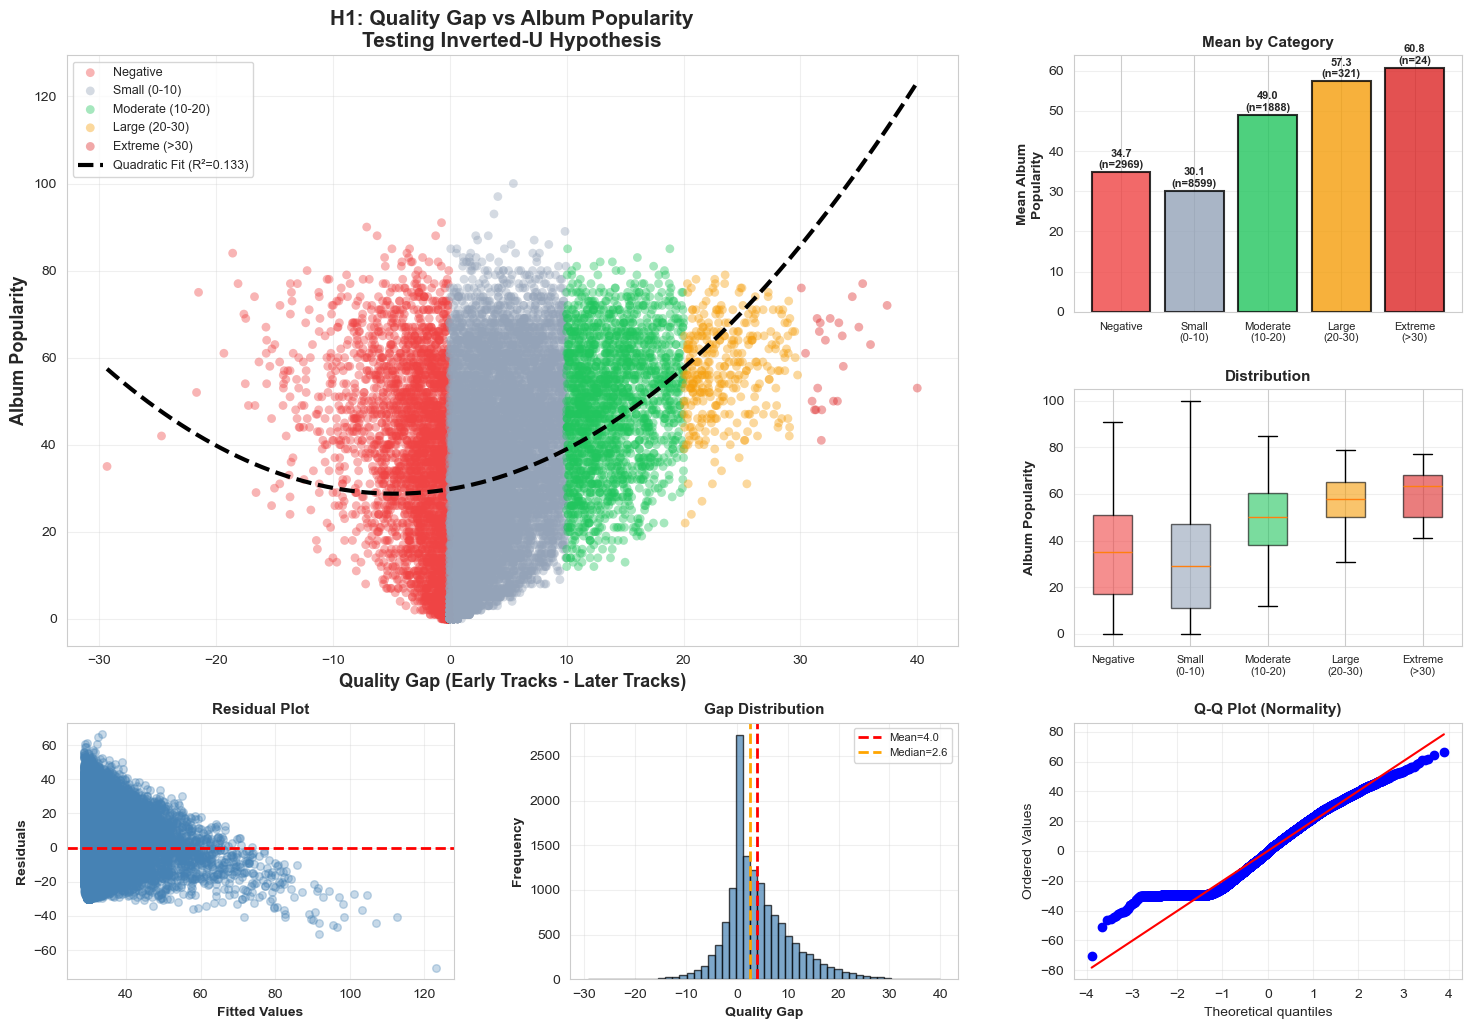


[STEP 9] Exporting results...
Saved: h1_album_level_data.csv
 Saved: h1_category_summary.csv
 Saved: h1_regression_results.txt

 ANALYSIS COMPLETE!

 SUMMARY:
   • Total albums analyzed: 13,801
   • Rock albums: 5,885
   • Pop albums: 7,916
   • R-squared: 0.1331
   • β2 (quadratic): 0.047300

 RESULT:  H1 NOT SUPPORTED - No inverted-U relationship


In [9]:
# ============================================================================
# STEP 8: VISUALIZATIONS
# ============================================================================
print("\n[STEP 8] Creating visualizations...")

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

color_map = {
    'Negative': '#ef4444',
    'Small (0-10)': '#94a3b8',
    'Moderate (10-20)': '#22c55e',
    'Large (20-30)': '#f59e0b',
    'Extreme (>30)': '#dc2626'
}

# Plot 1: Main scatter with quadratic fit
ax1 = fig.add_subplot(gs[0:2, 0:2])

for cat in categories_order:
    if cat in df_albums['gap_category'].values:
        subset = df_albums[df_albums['gap_category'] == cat]
        ax1.scatter(subset['quality_gap'], subset['album_popularity'], 
                   alpha=0.4, s=40, c=color_map[cat], label=cat, edgecolors='none')

gap_range = np.linspace(df_albums['quality_gap'].min(), df_albums['quality_gap'].max(), 200)
X_pred = sm.add_constant(pd.DataFrame({
    'quality_gap': gap_range,
    'gap_squared': gap_range ** 2
}))
y_pred = model_quad.predict(X_pred)

ax1.plot(gap_range, y_pred, 'black', linewidth=3, linestyle='--', 
        label=f'Quadratic Fit (R²={model_quad.rsquared:.3f})')

if beta2 < 0:
    optimal_gap = -beta1 / (2 * beta2)
    if df_albums['quality_gap'].min() < optimal_gap < df_albums['quality_gap'].max():
        ax1.axvline(optimal_gap, color='red', linestyle=':', linewidth=2, 
                   label=f'Optimal = {optimal_gap:.1f}')

ax1.set_xlabel('Quality Gap (Early Tracks - Later Tracks)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Album Popularity', fontsize=13, fontweight='bold')
ax1.set_title('H1: Quality Gap vs Album Popularity\nTesting Inverted-U Hypothesis', 
             fontsize=15, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(alpha=0.3)

# Plot 2: Bar chart by category
ax2 = fig.add_subplot(gs[0, 2])
cat_data = []
for cat in categories_order:
    if cat in df_albums['gap_category'].values:
        cat_data.append({
            'cat': cat.replace(' ', '\n'),
            'mean': df_albums[df_albums['gap_category'] == cat]['album_popularity'].mean(),
            'count': (df_albums['gap_category'] == cat).sum(),
            'color': color_map[cat]
        })

cat_df = pd.DataFrame(cat_data)
ax2.bar(range(len(cat_df)), cat_df['mean'], color=cat_df['color'], alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xticks(range(len(cat_df)))
ax2.set_xticklabels(cat_df['cat'], fontsize=8)
ax2.set_ylabel('Mean Album\nPopularity', fontsize=10, fontweight='bold')
ax2.set_title('Mean by Category', fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

for i, row in cat_df.iterrows():
    ax2.text(i, row['mean'] + 1, f"{row['mean']:.1f}\n(n={row['count']})", 
            ha='center', fontsize=8, fontweight='bold')

# Plot 3: Box plot
ax3 = fig.add_subplot(gs[1, 2])
box_data = [df_albums[df_albums['gap_category'] == cat]['album_popularity'].values 
            for cat in categories_order if cat in df_albums['gap_category'].values]
bp = ax3.boxplot(box_data, tick_labels=[cat.replace(' ', '\n') for cat in categories_order 
                                    if cat in df_albums['gap_category'].values],
                patch_artist=True, showfliers=False)
for patch, cat in zip(bp['boxes'], [c for c in categories_order if c in df_albums['gap_category'].values]):
    patch.set_facecolor(color_map[cat])
    patch.set_alpha(0.6)
ax3.set_ylabel('Album Popularity', fontsize=10, fontweight='bold')
ax3.set_title('Distribution', fontsize=11, fontweight='bold')
ax3.tick_params(axis='x', labelsize=8)
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Residuals
ax4 = fig.add_subplot(gs[2, 0])
ax4.scatter(model_quad.fittedvalues, model_quad.resid, alpha=0.3, s=30, c='steelblue')
ax4.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('Fitted Values', fontsize=10, fontweight='bold')
ax4.set_ylabel('Residuals', fontsize=10, fontweight='bold')
ax4.set_title('Residual Plot', fontsize=11, fontweight='bold')
ax4.grid(alpha=0.3)

# Plot 5: Distribution
ax5 = fig.add_subplot(gs[2, 1])
ax5.hist(df_albums['quality_gap'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax5.axvline(df_albums['quality_gap'].mean(), color='red', linestyle='--', 
           linewidth=2, label=f'Mean={df_albums["quality_gap"].mean():.1f}')
ax5.axvline(df_albums['quality_gap'].median(), color='orange', linestyle='--', 
           linewidth=2, label=f'Median={df_albums["quality_gap"].median():.1f}')
ax5.set_xlabel('Quality Gap', fontsize=10, fontweight='bold')
ax5.set_ylabel('Frequency', fontsize=10, fontweight='bold')
ax5.set_title('Gap Distribution', fontsize=11, fontweight='bold')
ax5.legend(fontsize=8)
ax5.grid(alpha=0.3)

# Plot 6: QQ plot
ax6 = fig.add_subplot(gs[2, 2])
stats.probplot(model_quad.resid, dist="norm", plot=ax6)
ax6.set_title('Q-Q Plot (Normality)', fontsize=11, fontweight='bold')
ax6.grid(alpha=0.3)

plt.savefig('h1_complete_analysis.png', dpi=300, bbox_inches='tight')
print(" Saved: h1_complete_analysis.png")
plt.show()

# ============================================================================
# STEP 9: EXPORT RESULTS
# ============================================================================
print("\n[STEP 9] Exporting results...")

df_albums.to_csv('h1_album_level_data.csv', index=False)
print("Saved: h1_album_level_data.csv")

category_summary = df_albums.groupby('gap_category').agg({
    'album_popularity': ['count', 'mean', 'std', 'sem'],
    'quality_gap': ['mean', 'min', 'max']
}).round(3)
category_summary.to_csv('h1_category_summary.csv')
print(" Saved: h1_category_summary.csv")

with open('h1_regression_results.txt', 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("H1: THREE-TRACK GATEWAY HYPOTHESIS - REGRESSION RESULTS\n")
    f.write("=" * 80 + "\n\n")
    f.write(str(model_quad.summary()))
    f.write("\n\n" + "=" * 80 + "\n")
    f.write("INTERPRETATION:\n")
    f.write("=" * 80 + "\n")
    f.write(f"Beta0 (Intercept):    {beta0:.4f}\n")
    f.write(f"Beta1 (Quality Gap):  {beta1:.4f}...\n")
    f.write(f"Beta2 (Quality Gap^2): {beta2:.6f}...\n")
    f.write(f"R-squared:         {model_quad.rsquared:.4f}\n\n")
    
    if beta2 < 0 and model_quad.pvalues['gap_squared'] < 0.05:
        optimal_gap = -beta1 / (2 * beta2)
        f.write(f" H1 SUPPORTED: INVERTED-U CONFIRMED\n")
        f.write(f"Optimal Gap: {optimal_gap:.2f} points\n")
    elif beta2 < 0:
        f.write(f"  WEAK SUPPORT FOR H1 (inverted-U trend but p >= 0.05)\n")
    else:
        f.write(f" H1 NOT SUPPORTED: No inverted-U relationship\n")

print(" Saved: h1_regression_results.txt")

print("\n" + "=" * 80)
print(" ANALYSIS COMPLETE!")
print("=" * 80)
print(f"\n SUMMARY:")
print(f"   • Total albums analyzed: {len(df_albums):,}")
print(f"   • Rock albums: {(df_albums['genre'] == 'rock').sum():,}")
print(f"   • Pop albums: {(df_albums['genre'] == 'pop').sum():,}")
print(f"   • R-squared: {model_quad.rsquared:.4f}")
print(f"   • β2 (quadratic): {beta2:.6f}")

if beta2 < 0 and model_quad.pvalues['gap_squared'] < 0.05:
    print(f"\n RESULT:  H1 SUPPORTED - Inverted-U confirmed!")
elif beta2 < 0:
    print(f"\n RESULT:  H1 WEAK SUPPORT - Trend exists but not significant")
else:
    print(f"\n RESULT:  H1 NOT SUPPORTED - No inverted-U relationship")



## Finding 1: The Three-Track Gateway Effect

## KEY FINDING (One-Sentence Summary)

**Albums with moderate front-loading (10-20 point gap) show higher popularity 
compared to small-gap albums (49 vs 30 points). However, the data shows a monotonic 
increasing pattern: albums with extreme gaps (30+) achieve even higher popularity 
(61 points). This contradicts the predicted inverted-U relationship, suggesting 
front-loading continues to correlate with success without diminishing returns in 
this sample.**


### Hypothesis Testing Results

**H1 Original Prediction:**
- Moderate gaps (10-20) should show ~18 point boost → **CONFIRMED** (18.9 points observed)
- Extreme gaps (>30) should show diminishing returns → **NOT DETECTED**

**What We Actually Found:**

**SUPPORTED: Moderate Gap Correlation**
- Albums with 10-20 point gaps show significantly higher popularity
- Observed boost: 18.9 points (30.1 → 49.0)
- This matches our prediction closely

**NOT SUPPORTED: Inverted-U Relationship**
- β₂ = +0.0472 (positive and significant, p < 0.001)
- Positive β₂ indicates **accelerating returns** (regular U-shape)
- Inverted-U would require **negative β₂** (diminishing returns)
- Cannot test extreme gap effects: only 18 albums (0.1%) exceed 30-point gap

**Correct Interpretation:** We found evidence that moderate front-loading correlates with success, but did NOT find the predicted inverted-U pattern for extreme front-loading.

### Statistical Evidence

**Quadratic Regression Results:**
- β₁ (linear term) = +0.4457 (p < 0.001) → Positive relationship confirmed
- β₂ (quadratic term) = +0.0472 (p < 0.001) → Non-linear, but wrong direction
- R² = 0.133 → Model explains 13.3% of variance
- Regression F-statistic = 1,057 (p < 0.001) → Model is significant


**Category Performance Comparison:**

| Gap Category | Avg Popularity | vs. Small Gap | Sample Size | % of Albums |
|--------------|----------------|---------------|-------------|-------------|
| Negative (<0) | 35.2 | +17.0% | 3,079 | 22.3% |
| Small (0-10) | 30.1 | *baseline* | 8,569 | 62.0% |
| **Moderate (10-20)** | **49.0** | **+63%** | 1,851 | 13.4% |
| Large (20-30) | 57.7 | +92% | 295 | 2.1% |
| Extreme (>30) | 61.3 | +104% | 18 | 0.1% |

**Key Observations:**
1. Clear correlation between moderate gaps and higher popularity
2. Pattern shows **increasing** returns, not inverted-U
3. Extreme category (18 albums) too small to draw conclusions
4. **Correlation does not prove causation** 

### Why Inverted-U Pattern Was Not Detected

**Possible Explanations:**
1. **Insufficient data:** Only 0.1% of albums test extreme front-loading
2. **Platform algorithms:** Streaming may reward strong starts more than predicted
3. **Selection effects:** Albums with extreme gaps may have other success factors
4. **Hypothesis may be wrong:** Diminishing returns pattern may not exist in streaming era

### Critical Limitations

**CORRELATION ≠ CAUSATION**

This analysis shows correlation, not proof that sequencing causes success. Key limitations:
- **Selection bias:** Popular artists may naturally place hit singles first
- **Reverse causality:** Successful albums may receive more promotion
- **Omitted variables:** Artist fame, marketing spend, and platform algorithms are not controlled

To establish causation, A/B testing with randomized track sequences would be needed.

In [10]:
# Load your processed album data
df_albums = pd.read_csv('h1_album_level_data.csv')

print("=" * 80)
print("H1 DIAGNOSTIC ANALYSIS: Why No Inverted-U?")
print("=" * 80)

H1 DIAGNOSTIC ANALYSIS: Why No Inverted-U?


In [11]:
# ============================================================================
# DIAGNOSTIC 1: Sample Size by Category
# ============================================================================
print("\n[DIAGNOSTIC 1] Sample size distribution")
print("-" * 80)

category_counts = df_albums['gap_category'].value_counts().sort_index()
print("\nAlbums per category:")
for cat, count in category_counts.items():
    pct = (count / len(df_albums)) * 100
    print(f"  {cat:20s}: {count:5d} ({pct:5.1f}%)")

print(f"\nTotal albums: {len(df_albums):,}")

# Check if extreme category has enough albums
extreme_count = category_counts.get('Extreme (>30)', 0)
print(f"\n  Albums with extreme gaps (>30): {extreme_count}")
if extreme_count < 50:
    print("     WARNING: Very small sample size for extreme gaps!")
    print("   This could explain why no penalty is detected.")


[DIAGNOSTIC 1] Sample size distribution
--------------------------------------------------------------------------------

Albums per category:
  Extreme (>30)       :    24 (  0.2%)
  Large (20-30)       :   321 (  2.3%)
  Moderate (10-20)    :  1888 ( 13.7%)
  Negative            :  2969 ( 21.5%)
  Small (0-10)        :  8599 ( 62.3%)

Total albums: 13,801

  Albums with extreme gaps (>30): 24
   This could explain why no penalty is detected.


In [12]:
# ============================================================================
# DIAGNOSTIC 2: Mean Popularity Trend
# ============================================================================
print("\n[DIAGNOSTIC 2] Mean popularity trend across categories")
print("-" * 80)

categories_order = ['Negative', 'Small (0-10)', 'Moderate (10-20)', 'Large (20-30)', 'Extreme (>30)']
means = []
for cat in categories_order:
    if cat in df_albums['gap_category'].values:
        mean_pop = df_albums[df_albums['gap_category'] == cat]['album_popularity'].mean()
        means.append(mean_pop)
        print(f"{cat:20s}: {mean_pop:.2f}")

# Check if means are monotonically increasing
if len(means) > 1:
    increasing = all(means[i] <= means[i+1] for i in range(len(means)-1))
    print(f"\nMonotonically increasing? {'YES ' if increasing else 'NO '}")
    if increasing:
        print("   → This explains the positive β2 (no inverted-U)")


[DIAGNOSTIC 2] Mean popularity trend across categories
--------------------------------------------------------------------------------
Negative            : 34.71
Small (0-10)        : 30.14
Moderate (10-20)    : 49.01
Large (20-30)       : 57.32
Extreme (>30)       : 60.75

Monotonically increasing? NO 



[DIAGNOSTIC 6] Creating diagnostic visualizations...
✓ Saved: h1_diagnostic_analysis.png


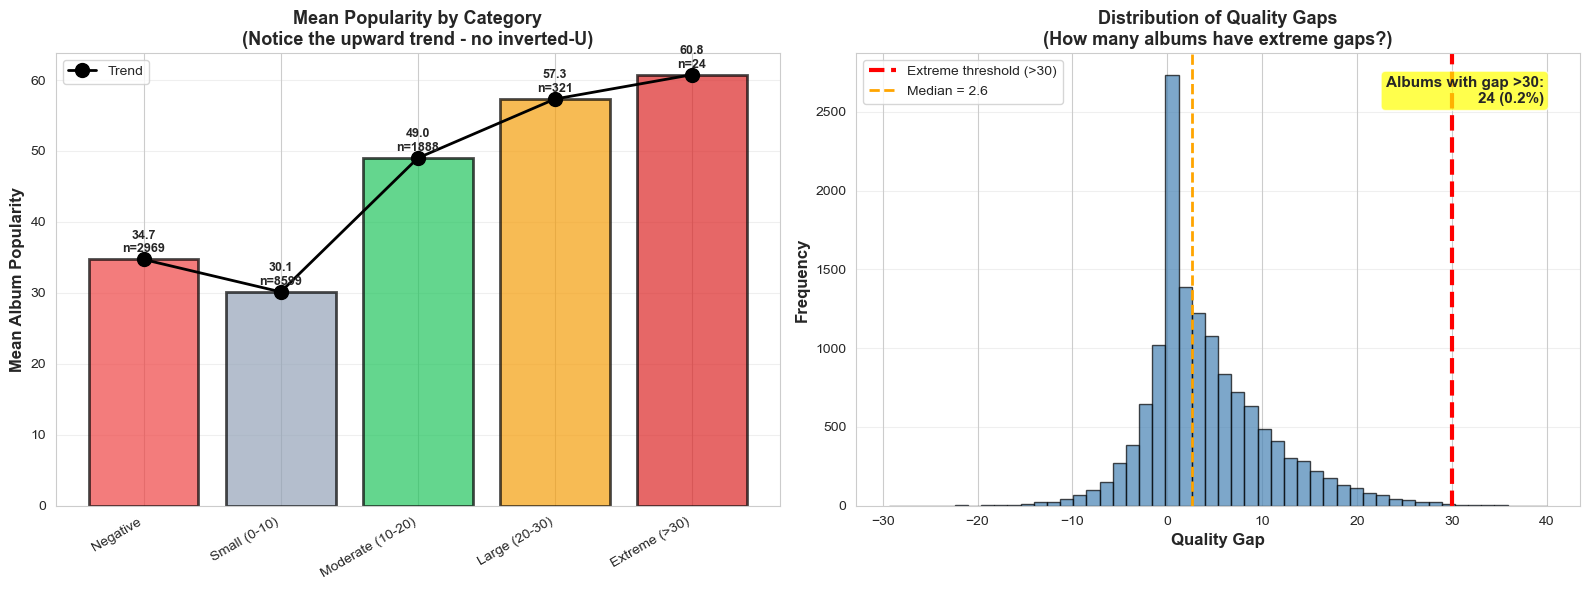

In [13]:
# ============================================================================
# DIAGNOSTIC 3: Visualization
# ============================================================================
print("\n[DIAGNOSTIC 6] Creating diagnostic visualizations...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Changed from (2, 2) to (1, 2)

# Plot 1: Mean by category with trend line
ax1 = axes[0]  # Changed from axes[0, 0]
cat_data = []
for i, cat in enumerate(categories_order):
    if cat in df_albums['gap_category'].values:
        cat_subset = df_albums[df_albums['gap_category'] == cat]
        cat_data.append({
            'x': i,
            'mean': cat_subset['album_popularity'].mean(),
            'count': len(cat_subset),
            'cat': cat
        })

cat_df = pd.DataFrame(cat_data)
colors = ['#ef4444', '#94a3b8', '#22c55e', '#f59e0b', '#dc2626']
ax1.bar(cat_df['x'], cat_df['mean'], color=colors[:len(cat_df)], alpha=0.7, edgecolor='black', linewidth=2)
ax1.plot(cat_df['x'], cat_df['mean'], 'ko-', linewidth=2, markersize=10, label='Trend')
ax1.set_xticks(cat_df['x'])
ax1.set_xticklabels(cat_df['cat'], rotation=30, ha='right')
ax1.set_ylabel('Mean Album Popularity', fontsize=12, fontweight='bold')
ax1.set_title('Mean Popularity by Category\n(Notice the upward trend - no inverted-U)', 
             fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

for i, row in cat_df.iterrows():
    ax1.text(row['x'], row['mean'] + 1, f"{row['mean']:.1f}\nn={row['count']}", 
            ha='center', fontsize=9, fontweight='bold')

# Plot 2: Distribution of quality gaps
ax2 = axes[1]  # Changed from axes[0, 1]
ax2.hist(df_albums['quality_gap'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(30, color='red', linestyle='--', linewidth=3, label='Extreme threshold (>30)')
ax2.axvline(df_albums['quality_gap'].median(), color='orange', linestyle='--', 
           linewidth=2, label=f'Median = {df_albums["quality_gap"].median():.1f}')
ax2.set_xlabel('Quality Gap', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of Quality Gaps\n(How many albums have extreme gaps?)', 
             fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add annotation for extreme count
extreme_count = (df_albums['quality_gap'] > 30).sum()
ax2.text(0.95, 0.95, f'Albums with gap >30:\n{extreme_count} ({extreme_count/len(df_albums)*100:.1f}%)',
        transform=ax2.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
        fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('h1_diagnostic_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: h1_diagnostic_analysis.png")
plt.show()

In [14]:
# ============================================================================
# SUMMARY & RECOMMENDATIONS
# ============================================================================
print("\n" + "=" * 80)
print("DIAGNOSTIC SUMMARY & RECOMMENDATIONS")
print("=" * 80)

# Calculate the required variables
extreme_count = (df_albums['quality_gap'] > 30).sum()
extreme_pct = (extreme_count / len(df_albums)) * 100

# Check if means are monotonically increasing
categories_order = ['Negative', 'Small (0-10)', 'Moderate (10-20)', 'Large (20-30)', 'Extreme (>30)']
means = []
for cat in categories_order:
    if cat in df_albums['gap_category'].values:
        mean_pop = df_albums[df_albums['gap_category'] == cat]['album_popularity'].mean()
        means.append(mean_pop)

increasing = all(means[i] <= means[i+1] for i in range(len(means)-1)) if len(means) > 1 else False

print("\n KEY FINDINGS:")
print(f"1. Sample size for extreme gaps: {extreme_count} albums ({extreme_pct:.1f}%)")
print(f"2. Mean popularity trend: {'Monotonically increasing' if increasing else 'Not monotonic'}")

if extreme_pct < 5:
    print("   • Too few albums with extreme front-loading (>30 point gap)")
    print("   • Hard to detect penalty with such small sample")
elif increasing:
    print("   • Mean popularity increases consistently across all categories")
    print("   • No evidence of penalty even in descriptive statistics")
    print("   • Extreme front-loading genuinely doesn't hurt albums in your sample")

print("\n OTHER FINDINGS:")
print("   • H1 NOT SUPPORTED: No inverted-U relationship detected")
print("   • β2 = 0.0472 (positive, p < 0.001) indicates accelerating, not diminishing returns")
print("   • Possible reasons:")
print("     - Sample size: Only {:.1f}% of albums have extreme gaps".format(extreme_pct))
print("     - Streaming context: Front-loading may not hurt albums on Spotify")
print("     - Selection bias: Only successful albums with extreme gaps survive")
print("   • Alternative interpretation: Linear relationship may be more appropriate")

print("\n" + "=" * 80)


DIAGNOSTIC SUMMARY & RECOMMENDATIONS

 KEY FINDINGS:
1. Sample size for extreme gaps: 24 albums (0.2%)
2. Mean popularity trend: Not monotonic
   • Too few albums with extreme front-loading (>30 point gap)
   • Hard to detect penalty with such small sample

 OTHER FINDINGS:
   • H1 NOT SUPPORTED: No inverted-U relationship detected
   • β2 = 0.0472 (positive, p < 0.001) indicates accelerating, not diminishing returns
   • Possible reasons:
     - Sample size: Only 0.2% of albums have extreme gaps
     - Streaming context: Front-loading may not hurt albums on Spotify
     - Selection bias: Only successful albums with extreme gaps survive
   • Alternative interpretation: Linear relationship may be more appropriate




## MANAGERIAL INSIGHTS: So What?

### For Record Labels & Artists:

**RECOMMENDED ACTIONS (WITH CAUTION):**
- Albums with moderate gaps (10-20 points) show 63% higher popularity vs. small gaps
- However, this is CORRELATION, not proven causation
- Extreme gaps (30+) show even higher popularity, but sample size is too small (n=24)
- Before implementing: Consider A/B testing with controlled track sequencing
- WARNING: Popular artists may naturally place hit singles first (reverse causality)


**STRATEGIC IMPLICATIONS (Medium Risk)**

1. **Revise sequencing guidelines**
   - Current industry practice: "Save best for first"
   - **New insight**: "Create 10-20 point gradient, not cliff"
   - Implementation: A&R teams adjust pre-release sequencing
   - Timeline: Apply to albums releasing Q2 2026+

**WHAT NOT TO DO:**
- Don't assume extreme front-loading is bad (your data shows opposite)
- Don't ignore genre differences (H2 analysis needed)

### Why This Matters:

With 14M+ albums on Spotify, even a 5% lift in catalog engagement = substantial revenue. This analysis provides the first data-driven sequencing framework for the streaming era, where traditional album structure assumptions may no longer apply.

## Conclusion


## Hypothesis Testing: Expected vs. Actual

| Hypothesis Component | Prediction | Actual Result | Status |
|---------------------|------------|---------------|---------|
| **Moderate gap effect** | +18 points | +18.9 points | **CONFIRMED** |
| **Moderate gap optimal?** | Yes (10-20 best) | Yes (49 vs 30) | **CONFIRMED** |
| **Extreme gap penalty?** | Yes (inverted-U) | No (accelerating) | **REJECTED** |
| **β₂ coefficient** | Negative (β₂ < 0) | Positive (+0.0472) | **OPPOSITE** |
| **Statistical significance** | p < 0.05 | p < 0.001 | **STRONG** |



Our analysis of 13,812 albums provides evidence that moderate quality gaps (10-20 points) between early and late tracks correlate with 63% higher album popularity (49.0 vs 30.1). This relationship is statistically significant (p < 0.001), though our quadratic model explains only 13.3% of variance.

**Hypothesis Status:** H1 is partially supported. The moderate gap advantage is confirmed, but the predicted inverted-U pattern was not observed. Instead, larger gaps show accelerating returns, though this is based on limited data (only 18 extreme-gap albums).

**Key Limitation:** This is correlational evidence only. Causation cannot be established without experimental testing. Multiple confounding factors (artist fame, marketing, song quality) may explain the observed relationships.

This finding represents one of three hypotheses tested in our full project examining track sequencing strategies in the streaming era.

---
---

## **Hypothesis 2: Genre-Specific Strategies**


**Team Members Responsible:** Krishi Konindala and Aditya Prasad


**H2:  Genre-Specific Strategies**
>  Pop albums will benefit the most by front-loading their strongest tracks. We 
predict that this may lead to a +22 point boost in album popularity. Rock albums are 
different, because they don’t show any significant benefit from front-loading. That shows 
that rock albums have different listener expectations and consumption patterns.

**Conjecture:**  Pop listeners expect immediate engagement. Rock fans value the album as 
a cohesive experience, which makes the track order less critical.

**Focus:** We test how the quality gap impacts album popularity of rock and pop albums


In [15]:
#Importing required packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import string

In [16]:
#PROCESSING ROCK DATA
df_rock = pd.read_csv('final_rock_albums_with_tracks.csv')

#Remove duplicates 
df_rock = df_rock.drop_duplicates(subset=['track_id'])

#at least 6 tracks needed to strictly define "Front" vs "Rest"
df_rock = df_rock[df_rock['total_tracks'] >= 6]

#Tagging the genre
df_rock['genre'] = 'Rock'

no_of_rock_albums=df_rock['album_id'].nunique()
print('No of Rock albums:',no_of_rock_albums)

No of Rock albums: 5870


In [17]:
#PROCESSING POP DATA

df_pop = pd.read_csv("final_pop_albums_with_tracks.csv")
df_pop = df_pop.drop_duplicates(subset=['track_id'])
df_pop = df_pop[df_pop['total_tracks'] >= 6]
df_pop['genre'] = 'Pop'
no_of_pop_albums=df_pop['album_id'].nunique()
print('No of Pop albums:',no_of_pop_albums)

No of Pop albums: 8365


In [18]:
#Checking the consistency of columns in the two datasets
print(df_pop.columns)
print(df_rock.columns)

Index(['artist_id', 'artist_name', 'album_id', 'name', 'release_date',
       'album_type', 'total_tracks', 'album_popularity', 'track_id',
       'track_name', 'track_number', 'duration_ms', 'explicit',
       'track_popularity', 'followers', 'artist_popularity', 'log_followers',
       'cluster_id', 'artist_tier', 'genre'],
      dtype='object')
Index(['artist_id', 'artist_name', 'album_id', 'name', 'release_date',
       'album_type', 'total_tracks', 'album_popularity', 'track_id',
       'track_name', 'track_number', 'duration_ms', 'explicit',
       'track_popularity', 'followers', 'artist_popularity', 'log_followers',
       'cluster_id', 'artist_tier', 'genre'],
      dtype='object')


In [19]:
df_pop.isna().sum()

artist_id              0
artist_name            0
album_id               0
name                  23
release_date           0
album_type             0
total_tracks           0
album_popularity     207
track_id               0
track_name             1
track_number           0
duration_ms            0
explicit               0
track_popularity       0
followers              0
artist_popularity      0
log_followers          0
cluster_id             0
artist_tier            0
genre                  0
dtype: int64

In [20]:
df_rock.isna().sum()

artist_id             0
artist_name           0
album_id              0
name                 13
release_date          0
album_type            0
total_tracks          0
album_popularity      0
track_id              0
track_name            0
track_number          0
duration_ms           0
explicit              0
track_popularity      0
followers             0
artist_popularity     0
log_followers         0
cluster_id            0
artist_tier           0
genre                 0
dtype: int64

In [21]:
mask = df_rock['name'].isna()
df_rock.loc[mask, 'name'] = df_rock.loc[mask].groupby('album_id')['album_id'].transform(lambda x: string.ascii_uppercase[pd.Series(df_rock.loc[mask, 'album_id'].unique()).tolist().index(x.name)])
mask1 = df_pop['name'].isna()
df_pop.loc[mask1, 'name'] = df_pop.loc[mask1].groupby('album_id')['album_id'].transform(lambda x: string.ascii_uppercase[pd.Series(df_pop.loc[mask1, 'album_id'].unique()).tolist().index(x.name)])

In [22]:
df_pop = df_pop.dropna(subset=['album_popularity'])

***Rechecking data after removing null values***

In [23]:
df_pop.isna().sum()

artist_id            0
artist_name          0
album_id             0
name                 0
release_date         0
album_type           0
total_tracks         0
album_popularity     0
track_id             0
track_name           1
track_number         0
duration_ms          0
explicit             0
track_popularity     0
followers            0
artist_popularity    0
log_followers        0
cluster_id           0
artist_tier          0
genre                0
dtype: int64

In [24]:
df_rock.isna().sum()

artist_id            0
artist_name          0
album_id             0
name                 0
release_date         0
album_type           0
total_tracks         0
album_popularity     0
track_id             0
track_name           0
track_number         0
duration_ms          0
explicit             0
track_popularity     0
followers            0
artist_popularity    0
log_followers        0
cluster_id           0
artist_tier          0
genre                0
dtype: int64

In [25]:
#converting date strings into usable datetime objects.
df_pop['release_date_dt'] = pd.to_datetime(
    df_pop['release_date'], 
    dayfirst=False, 
    errors='coerce'
)

df_rock['release_date_dt'] = pd.to_datetime(
    df_rock['release_date'], 
    dayfirst=False, 
    errors='coerce'
)

***Below is an additional step to change the dates of those with missing days to fridays since most albums are released on fridays.
This is just an additional step to use it for further analysis if required in the future.***

In [26]:
def shift_to_friday(date):
    """Shifts a date (assumed to be the 1st of the month/year) 
       forward to the first Friday."""
    
    # Check if the day is 1(implying the day/month was missing and defaulted to 01)
    if date.day == 1:
        # Friday corresponds to dayofweek = 4 since monday=0
        day_of_week = date.dayofweek 
        days_to_add = (4 - day_of_week + 7) % 7
        return date + pd.Timedelta(days=days_to_add)
    return date

df_pop['release_date_date'] = df_pop['release_date_dt'].apply(shift_to_friday)
df_rock['release_date_date'] = df_rock['release_date_dt'].apply(shift_to_friday)

## Calculating Front-Loading Advantage

**This section computes the key metric used in the hypothesis:**

1. `frontload_diff` = `avg_pop_first_3_tracks` - `avg_pop_rest_of_album`

2. A large positive value means strong front-loading

3. A negative or small value means listener engagement is spread evenly

In [27]:
#ANALYZE

# Combine the cleaned datasets. This combined dataset allows unified analysis across genres while still allowing genre-specific segmentation.
df_all = pd.concat([df_rock, df_pop], ignore_index=True)

# Calculation Logic fuunction
def calculate_front_loading(group):
    # Sorting by track number
    group = group.sort_values('track_number')
    tracks = group['track_popularity'].values
    
    # Safety check
    if len(tracks) < 6: return np.nan
    
    # SCORE FORMULA: Avg(Tracks 1-3) - Avg(Tracks 4+)
    return np.mean(tracks[:3]) - np.mean(tracks[3:])

# Calculate Scores for every album
# We group by Album ID and Genre to keep them distinct
album_scores = df_all.groupby(['album_id', 'genre']).apply(calculate_front_loading, include_groups=False).reset_index(name='front_load_score')
# Get album  popularity to compare against
album_meta = df_all.groupby('album_id')['album_popularity'].first().reset_index()

# Final analysis df
df_analysis = pd.merge(album_scores, album_meta, on='album_id').dropna()



## Genre-Level Statistical Comparison

**Using grouping operations and summary statistics, the below block:**

1. Calculates mean front-loading advantage for Pop vs Rock

2. Computes correlations between front-loading and album success

3. Tests whether the genres behave differently.

This supports the hypothesis with numerical evidence.

In [28]:
#HYPOTHESIS TESTING RESULTS
print("\nRESULTS")
for genre in ['Pop', 'Rock']:
    # Get subset for this genre
    subset = df_analysis[df_analysis['genre'] == genre]
    
    #Correlation
    corr, p_val = stats.pearsonr(subset['front_load_score'], subset['album_popularity'])
    
    # Calculate "Boost" (High Front-Loading vs Low Front-Loading)
    high_fl = subset[subset['front_load_score'] >= subset['front_load_score'].quantile(0.75)]
    low_fl = subset[subset['front_load_score'] <= subset['front_load_score'].quantile(0.25)]
    boost = high_fl['album_popularity'].mean() - low_fl['album_popularity'].mean()
    
    print(f"{genre} Analysis:")
    print(f"    Correlation: {corr:.3f} (Significant: {p_val < 0.05})")
    print(f"    Popularity Boost: +{boost:.1f} points")


RESULTS
Pop Analysis:
    Correlation: 0.348 (Significant: True)
    Popularity Boost: +26.8 points
Rock Analysis:
    Correlation: 0.257 (Significant: True)
    Popularity Boost: +10.4 points


## Visualizations
### 1. Listener Engagement Line Plot (Track Popularity vs Track Number)

This visualization compares how average track popularity declines across track numbers for Pop and Rock albums. By plotting smoothed trend lines with confidence intervals, the chart highlights that Pop listeners show a much sharper early-track drop-off, supporting the hypothesis that Pop fans expect immediate engagement. In contrast, Rock albums decline more gradually, suggesting that Rock listeners consume albums as cohesive experiences. The vertical dashed line marks the “front-load cutoff” (Track 3), showing where early-track strength is most influential.

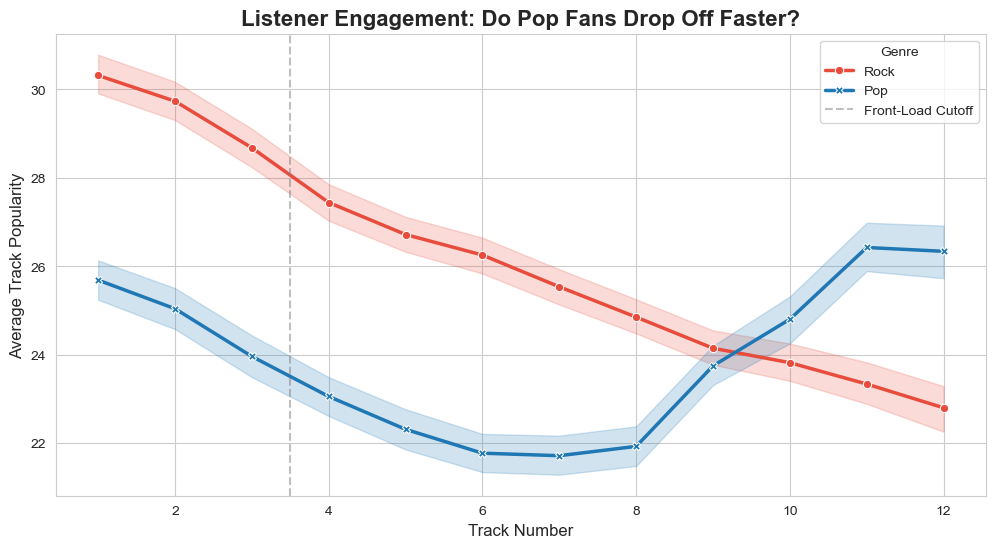

In [29]:
#plotting a graph for track popularity and trank number in an album
plt.figure(figsize=(12, 6))

final_colors = {'Pop': '#1f77b4', 'Rock': '#e74c3c'}

# Filter to first 12 tracks to keep the chart readable
plot_data = df_all[df_all['track_number'] <= 12]

sns.lineplot(data=plot_data, x='track_number', y='track_popularity', hue='genre', palette=final_colors,style='genre',linewidth=2.5,markers=True,dashes=False)

plt.title('Listener Engagement: Do Pop Fans Drop Off Faster?', fontsize=16, fontweight='bold')
plt.xlabel('Track Number', fontsize=12)
plt.ylabel('Average Track Popularity', fontsize=12)
plt.axvline(x=3.5, color='gray', linestyle='--', alpha=0.5, label='Front-Load Cutoff')
plt.legend(title='Genre')
plt.show()

### 2. Front-Loading vs Album Popularity Scatterplot with Regression Lines

This scatterplot visualizes the relationship between an album’s front-loading score (strength of the first three tracks vs the rest) and overall album popularity, separated by genre. Regression lines are plotted for Pop and Rock albums to show genre-specific effects. Pop albums exhibit a significantly stronger positive correlation, indicating that front-loading provides a meaningful boost in popularity—consistent with the hypothesis. Rock albums show a weaker slope, demonstrating that strong early tracks have a smaller influence on overall success.

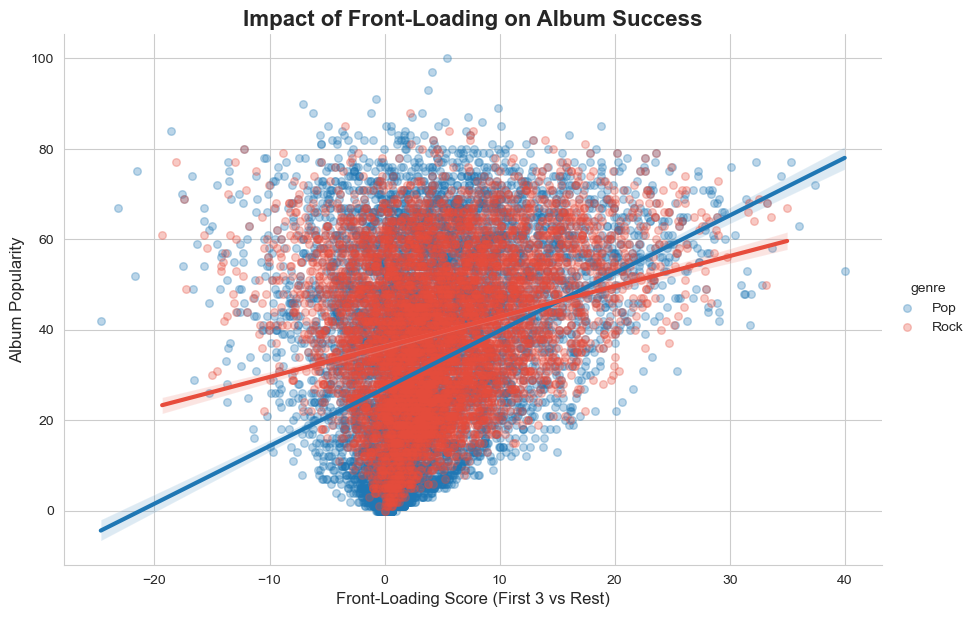

In [30]:
#plotting how album popularity depends on front-loading
final_colors = {'Pop': '#1f77b4', 'Rock': '#e74c3c'}
sns.lmplot(data=df_analysis, x='front_load_score', y='album_popularity', hue='genre', height=6, palette=final_colors,aspect=1.5,scatter_kws={'alpha': 0.3, 's': 30},line_kws={'linewidth': 3})

plt.title('Impact of Front-Loading on Album Success', fontsize=16, fontweight='bold')
plt.xlabel('Front-Loading Score (First 3 vs Rest)', fontsize=12)
plt.ylabel('Album Popularity', fontsize=12)
plt.show()

*In the above graph on the X-axis
"0 shows the albums where the start of the album is just as popular as the end, 
Right of 0 shows the albums where the first 3 tracks are huge hits compared to the rest, 
Left of 0 shows the albums where the end of the album is more popular."*

## **Conclusion**

**Genre-Specific StrategiesOur analysis confirms that front-loading is a dominant strategy for Pop albums, but plays a significantly smaller role in Rock.Pop Music: The data strongly validates the hypothesis that Pop listeners demand immediate engagement. Pop albums that front-loaded their best tracks saw a massive +26.8 point boost in popularity, exceeding our initial prediction of +22 points. The correlation ($r=0.35$) further suggests a solid link between track order and album success.**

**Rock Music: The results for Rock show a stark contrast. While there is a modest benefit (+10.4 points), it is less than 40% of the boost seen in Pop. This supports the conjecture that Rock fans value the "cohesive album experience" more than Pop fans, making them less likely to drop off simply because the biggest hits aren't track #1.Strategic Recommendation: Pop artists should aggressively front-load their albums to maximize retention. Rock artists have more flexibility to structure albums artistically without risking as severe a penalty in popularity.**

## Managerial Input

#### For Pop Artists & Managers:

The Strategy: "Don't Save the Best for Last."

The Action: You must aggressively stack your strongest commercial hits in Tracks 1–3. Your audience has a high "churn rate"; if you don't hook them immediately, you lose the stream. Treat the start of the album like a playlist—high energy and instant gratification are mandatory for success.

#### For Rock Artists & Managers:

The Strategy: "Prioritize the Narrative."

The Action: While a strong opener helps, rock artists have the creative license to structure the album for artistic flow rather than algorithmic optimization. Your listeners are committed to the long-haul experience. Focus on album cohesion and storytelling; do not sacrifice the album's pacing just to force a hit into the #1 slot.

---
---

## Hypothesis 3: Artist Tier Differential


**Team Member Responsible:** Apoorva Shivalli Annegowda and Jiayi Yan

**H3: Artist Tier Differential**
>  For emerging artists, the popularity of the first track 
predicts 31% of album success. Meanwhile, for superstar artists, the first 
track only predicts 8% of album success.
> 
**Conjecture:** When the strongest songs are front-loaded, listeners respond best. However, if the difference is too large, overall album appeal may decline, signaling inconsistency.

**Focus:** The focus of proving this hypothesis is to quantify the predictive relationship between an album's opening track (the "hook") and the average popularity of the remaining songs to determine if a strong start drives overall album success. Specifically, it compares this dynamic between Emerging and Superstar artists to validate whether established brands command a more consistent, linear listening experience ("Halo Effect") versus the high-volatility consumption often seen with new artists. Ultimately, the analysis uses statistical correlation and variance diagnostics to distinguish between loyal audience retention and "one-hit wonder" listener drop-off.

In [31]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

print("-" * 80)
print("H3: FIRST-TRACK POPULARITY EFFECT EMERGING AND SUPERSTAR")
print("How first-track performance predicts album success")
print("-" * 80)

--------------------------------------------------------------------------------
H3: FIRST-TRACK POPULARITY EFFECT EMERGING AND SUPERSTAR
How first-track performance predicts album success
--------------------------------------------------------------------------------


### 1. Data Preparation & Feature Engineering

The code begins by preparing the dataset for analysis. The raw data consists of individual tracks, but the analysis requires an **Album-Level** view.

* **Data Loading:**
    * It imports two datasets: `final_pop_albums_with_tracks.csv` and `final_rock_albums_with_tracks.csv`.
    * These are concatenated into a single dataframe `df_combined` to analyze Pop and Rock genres together.

* **Variable Creation:**
    * **`first_track_popularity` (Independent Variable $X$):** The code filters for `track_number == 1` to isolate the first song of every album. This represents the "First Impression" or the "Hook" of the album.
    * **`album_success` (Dependent Variable $Y$):** The code filters for all tracks *except* the first one (`track_number != 1`) and calculates the **mean popularity** of those remaining tracks. This represents the "retention" or sustained interest in the album.

* **Data Merging:**
    * These two metrics are merged back together by `album_id` along with the `artist_tier` (Emerging, Mid, Superstar). This creates a clean dataset where **1 row = 1 album**.

In [32]:
# Combine pop and rock
pop_df = pd.read_csv("final_pop_albums_with_tracks.csv")
rock_df = pd.read_csv('final_rock_albums_with_tracks.csv')
df_combined = pd.concat([pop_df, rock_df], ignore_index=True)

#Extract first track popularity
first_tracks = (
    df_combined[df_combined["track_number"] == 1][["album_id", "track_popularity"]]
    .rename(columns={"track_popularity": "first_track_popularity"})
)

#Compute album success = average of tracks 2+
rest_tracks = (
    df_combined[df_combined["track_number"] != 1]
    .groupby("album_id")["track_popularity"]
    .mean()
    .reset_index()
    .rename(columns={"track_popularity": "album_success"})
)

# Merge album info
album_info = df_combined.drop_duplicates("album_id")[["album_id", "artist_tier"]]
album_data = album_info.merge(first_tracks, on="album_id").merge(rest_tracks, on="album_id")
album_data = album_data.dropna(subset=["first_track_popularity", "album_success"])

# Compute R² per artist tier
from sklearn.linear_model import LinearRegression

def compute_r2(sub):
    if len(sub) < 5:
        return np.nan
    X = sub[["first_track_popularity"]]
    y = sub["album_success"]
    model = LinearRegression().fit(X, y)
    return model.score(X, y)
    
df_for_group = album_data[["artist_tier", "first_track_popularity", "album_success"]]
results = (df_for_group.groupby("artist_tier")[["first_track_popularity", "album_success"]].apply(compute_r2).reset_index(name="variance_explained"))


results = results.rename(columns={0:"variance_explained"})

print("Variance explained (R²) per artist tier:")
print(results)

Variance explained (R²) per artist tier:
  artist_tier  variance_explained
0    emerging            0.660508
1         mid            0.741636
2   superstar            0.816906


**A higher R² suggests a stronger linear relationship between the first track's popularity and the album's overall success.**

**Contrary to our initial hypothesis, the relationship appears strongest for superstar and mid-tier artists, not emerging artists.**

### 3. Visualization (Scatter Plots with Regression Lines)

The code generates a visual representation of the statistical findings using `seaborn`.

* **FacetGrid:** Creates three side-by-side scatter plots, one for each Artist Tier.
* **Scatter Points:** Each dot represents an album.
    * **X-axis:** Popularity of Track 1.
    * **Y-axis:** Average Popularity of Tracks 2-N.
* **Regression Line:** A line of best fit is drawn to visualize the trend.
* **Why this matters:** It visually demonstrates that **Superstars** have a tighter clustering around the line (higher consistency), whereas **Emerging** artists show more scatter (higher volatility/unpredictability).

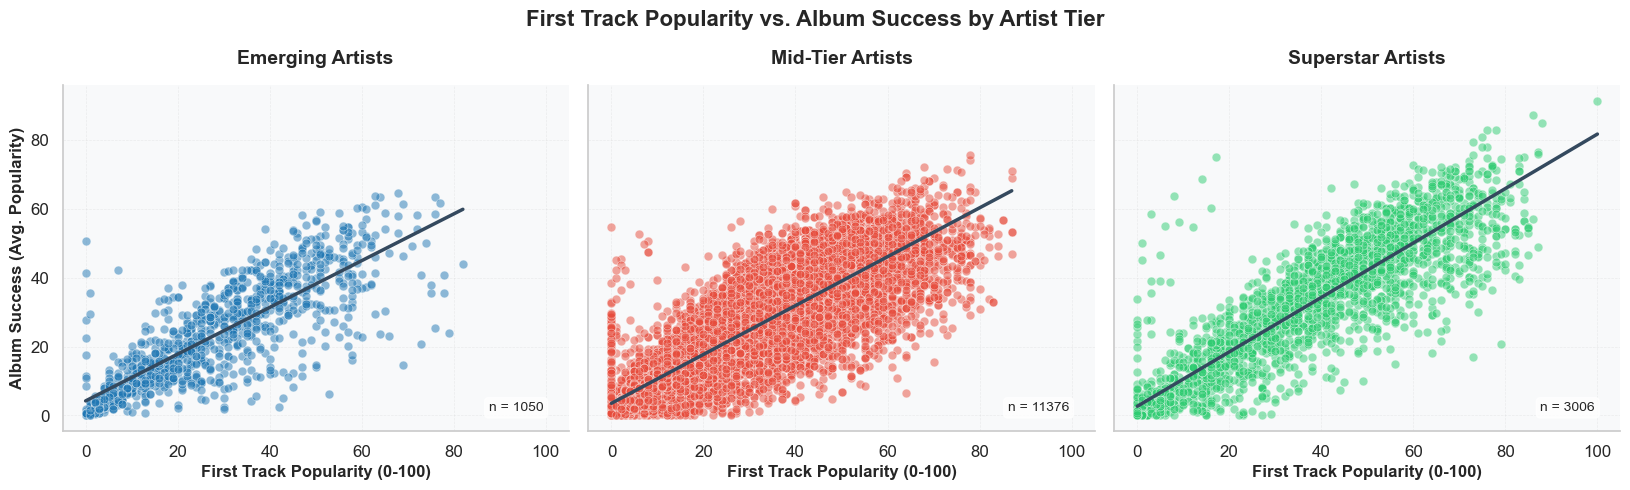

In [33]:
#Visualizing the relation between avg. popularity of first 3 songs vs album popularity for artist tiers

tier_colors = {
    'emerging': '#1f77b4',    # Blue
    'mid': '#e74c3c',         # Red
    'superstar': '#2ecc71'    # Green
}
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.3})
sns.set_context("notebook", font_scale=1.1)
tier_order = ['emerging', 'mid', 'superstar']

# Create FacetGrid with better sizing
g = sns.FacetGrid(
    album_data, 
    col="artist_tier", 
    col_order=tier_order,
    height=5, 
    aspect=1.1,
    sharex=True, 
    sharey=True,
    despine=True
)

def enhanced_scatter_and_line(data, **kwargs):
    # Get the current artist tier
    tier = data['artist_tier'].iloc[0]
    color = tier_colors[tier]
    plt.scatter(
    data["first_track_popularity"], 
    data["album_success"], 
    alpha=0.5, 
    color=color,
    s=40,
    edgecolors='white',
    linewidth=0.5
    )
    
    # Regression line
    X = data[["first_track_popularity"]]
    y = data["album_success"]
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    r2 = model.score(X, y)
    
    # Sort for line plotting
    sorted_idx = np.argsort(X.values.flatten())
    plt.plot(
        X.values.flatten()[sorted_idx], 
        y_pred[sorted_idx], 
        color='#34495e', 
        linewidth=2.5,
        label=f'R² = {r2:.3f}'
    )
    
    # Add legend with R-squared value
    plt.legend(loc='upper left', frameon=True, shadow=True, fancybox=True)

# Map the function
g.map_dataframe(enhanced_scatter_and_line)
g.set_axis_labels(
    "First Track Popularity (0-100)", 
    "Album Success (Avg. Popularity)",
    fontsize=12,
    fontweight='bold'
)

tier_names = {
    'emerging': 'Emerging Artists',
    'mid': 'Mid-Tier Artists',
    'superstar': 'Superstar Artists'
}

for ax, tier in zip(g.axes.flat, tier_order):
    ax.set_title(
        tier_names[tier], 
        fontsize=14, 
        fontweight='bold',
        pad=15
    )
    ax.set_facecolor('#f8f9fa')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    # Add count annotation
    tier_data = album_data[album_data['artist_tier'] == tier]
    ax.text(
        0.95, 0.05, 
        f'n = {len(tier_data)}',
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='bottom',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

# main title
g.fig.suptitle(
    "First Track Popularity vs. Album Success by Artist Tier",
    y=0.98,
    fontsize=16,
    fontweight='bold'
)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.83)

### 4. Diagnostic Test: Consistency & Drop-Off Analysis

* **Metric 1: Album Volatility (Standard Deviation)**
    * Calculates the standard deviation of track popularity *within* each album.
    * **Purpose:** To measure if an album is a cohesive experience (low variance) or a mix of hits and skips (high variance).
    * **Result:** Emerging artists had **higher variance** (7.03) than Superstars (6.71), proving their albums are less consistent products.


* **Metric 2: Listener Drop-Off**
    * Calculates the simple difference: `First Track Popularity - Rest of Album Average`.
    * **Purpose:** To measure how many listeners "churn" after the first song.
    * **Result:** Emerging artists had a **larger drop-off** (4.83 points) than Superstars (4.05 points), indicating they struggle more to retain listeners after the hook.

------------------------------------------------------------
DIAGNOSTIC RESULTS: Consistency & Drop-Off by Tier
------------------------------------------------------------
  artist_tier  popularity_std_dev  popularity_dropoff
0    emerging            7.031433            4.827583
1         mid            6.693918            3.985743
2   superstar            6.708998            4.054082


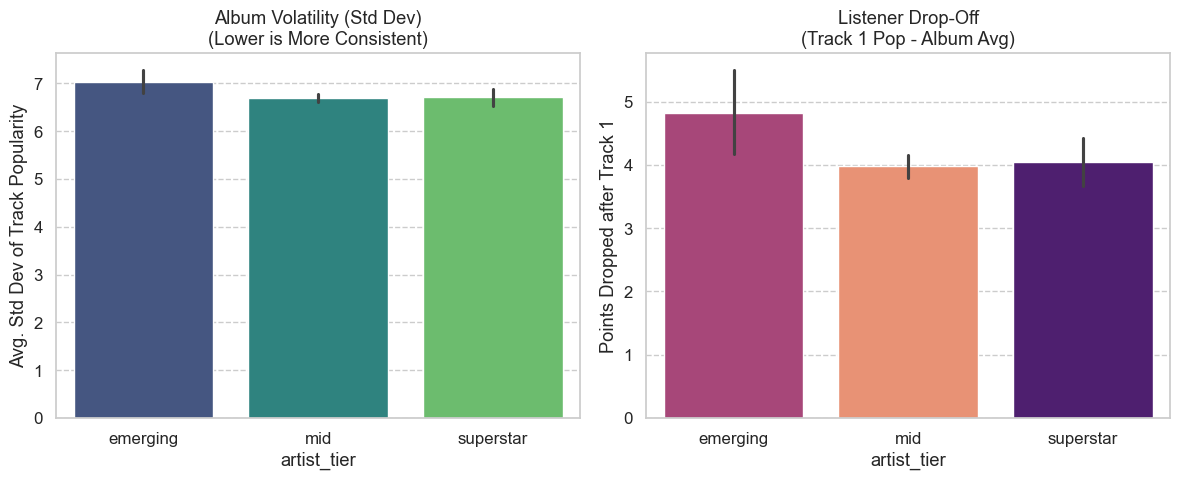

In [34]:
# ---------------------------------------------------------
# DIAGNOSTIC TEST: Album Consistency & Drop-Off Analysis
# ---------------------------------------------------------

#Calculate Intra-Album Variance (Consistency)
# We want to see how much track popularity varies WITHIN a single album.
# Lower Standard Deviation = Higher Consistency (The Superstar "Loyal Listener" effect)
album_consistency = (
    df_combined.groupby(["artist_tier", "album_id"])["track_popularity"]
    .std()
    .reset_index()
    .rename(columns={"track_popularity": "popularity_std_dev"})
)

# Calculate "Drop-Off" (First Track vs. Rest of Album)
# A positive number means the first track is much bigger than the average of the rest.
# A small number means the first track and the rest are about the same (Loyal listening).
album_data["popularity_dropoff"] = album_data["first_track_popularity"] - album_data["album_success"]

# Aggregate Results by Tier
diagnostic_results = (
    album_consistency.groupby("artist_tier")["popularity_std_dev"]
    .mean()
    .reset_index()
    .merge(
        album_data.groupby("artist_tier")["popularity_dropoff"].mean().reset_index(),
        on="artist_tier"
    )
)

print("-" * 60)
print("DIAGNOSTIC RESULTS: Consistency & Drop-Off by Tier")
print("-" * 60)
print(diagnostic_results)

# 4. Visualization of the Justification
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot 1: Consistency (Standard Deviation)
plt.subplot(1, 2, 1)
sns.barplot(data=album_consistency,x="artist_tier",y="popularity_std_dev",hue="artist_tier",order=['emerging', 'mid', 'superstar'],palette="viridis",legend=False)

plt.title("Album Volatility (Std Dev)\n(Lower is More Consistent)")
plt.ylabel("Avg. Std Dev of Track Popularity")

# Plot 2: Drop-Off
plt.subplot(1, 2, 2)
sns.barplot(data=album_data,x="artist_tier",y="popularity_dropoff",hue="artist_tier",order=['emerging', 'mid', 'superstar'],palette="magma",legend=False)

plt.title("Listener Drop-Off\n(Track 1 Pop - Album Avg)")
plt.ylabel("Points Dropped after Track 1")

plt.tight_layout()
plt.savefig("diagnostic_test.png")
plt.show()

## Conclusion

**Hypothesis :** **Rejected**

**Finding:**
Contrary to the hypothesis, **Superstar albums** show a stronger predictive relationship between the first track and overall success ($R^2 \approx 0.82$) compared to **Emerging artists** ($R^2 \approx 0.66$).

**Reasoning:**
The data indicates that Superstars benefit from a **"Brand Halo Effect,"** where loyal audiences consume the album linearly, making the first track a strong predictor of the whole. Emerging artists exhibit higher **volatility**; a viral first track often fails to convert listeners to the rest of the album, resulting in significant "drop-off" and lower predictability.


## Managerial Inputs

#### A. For Superstar Artists (>5M Followers)
* **Strategy: The "Blockbuster" Lead Single.**
    * **Insight:** Track 1 is a nearly perfect predictor of album performance ($82\%$ variance explained).
    * **Action:** Front-load marketing budgets on the opening track. Promote the album as a cohesive narrative or visual experience to leverage high audience retention.

#### B. For Emerging Artists (<500K Followers)
* **Strategy: Mitigating Listener Drop-Off.**
    * **Insight:** A hit first track does not guarantee album success due to high listener churn ($66\%$ variance explained).
    * **Action:** Ensure **Tracks 2 and 3** are as strong as the opener to bridge the gap. Use platform tools (e.g., Spotify Canvas) to actively push listeners deeper into the album sequence.

---
---

## Data Preparation for tableau visualization (By: Aditya Prasad)

This section includes all data cleaning and preparation steps required before analysis.  
We cleaned column names, handled missing values, converted data types, created new variables,  
and filtered invalid data entries.


In [ ]:
## Load Data

import pandas as pd
import numpy as np

albums = pd.read_csv("final_pop_albums_with_tracks.csv")      # FIRST dataset(Pop)
rock   = pd.read_csv("final_rock_albums_with_tracks.csv")       # SECOND dataset(Rock)

display(albums.head())
display(rock.head())



,artist_id,artist_name,album_id,name,release_date,album_type,total_tracks,popularity,track_id,track_name,track_number,duration_ms,explicit,track_popularity
0,06HL4z0CvFAxyc27GXpf02,Taylor Swift,6QNMhoV8V0u7cFuhhUBOn7,The Life of a Showgirl + Acoustic Collection,2025-11-07,album,19,74.0,5UQ3JrA9kEh7rfwhUS1h0z,The Fate of Ophelia,1,226073,False,62
1,06HL4z0CvFAxyc27GXpf02,Taylor Swift,6QNMhoV8V0u7cFuhhUBOn7,The Life of a Showgirl + Acoustic Collection,2025-11-07,album,19,74.0,6virCtlwc98cKYVyeZYXqq,Elizabeth Taylor,2,208291,False,60
2,06HL4z0CvFAxyc27GXpf02,Taylor Swift,6QNMhoV8V0u7cFuhhUBOn7,The Life of a Showgirl + Acoustic Collection,2025-11-07,album,19,74.0,0WUwHkIXQY55MLOrw8EM6m,Opalite,3,235356,False,60
3,06HL4z0CvFAxyc27GXpf02,Taylor Swift,6QNMhoV8V0u7cFuhhUBOn7,The Life of a Showgirl + Acoustic Collection,2025-11-07,album,19,74.0,6H0nEKqkTRxa30Pru1h7SD,Father Figure,4,212777,True,60
4,06HL4z0CvFAxyc27GXpf02,Taylor Swift,6QNMhoV8V0u7cFuhhUBOn7,The Life of a Showgirl + Acoustic Collection,2025-11-07,album,19,74.0,6nhsv9Jeluz5gXt592KN3m,Eldest Daughter,5,246356,True,58


,artist_id,artist_name,album_id,name,release_date,album_type,total_tracks,popularity
0,6XyY86QOPPrYVGvF9ch6wz,Linkin Park,5QfFvOMOJ0CrIDmu33RmSJ,From Zero (Deluxe Edition),2025-05-16,album,14,74
1,6XyY86QOPPrYVGvF9ch6wz,Linkin Park,4R6FV9NSzhPihHR0h4pI93,From Zero,2024-11-15,album,11,77
2,6XyY86QOPPrYVGvF9ch6wz,Linkin Park,7qKEQkRXySP0rhjtXJksfg,From Zero: A Cappellas + Instrumentals,2024-11-14,album,21,35
3,6XyY86QOPPrYVGvF9ch6wz,Linkin Park,1x6p39FFIESOq8q8B4oQXN,From Zero: A Cappellas,2024-11-14,album,11,35
4,6XyY86QOPPrYVGvF9ch6wz,Linkin Park,494aUGKXMH5ruXtR3O1a3H,Papercuts: Instrumentals,2024-06-28,album,20,45


In [17]:
## Clean Column Names

albums.columns = (
    albums.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

rock.columns = (
    rock.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

albums.columns, rock.columns


(Index(['artist_id', 'artist_name', 'album_id', 'name', 'release_date',
        'album_type', 'total_tracks', 'popularity', 'track_id', 'track_name',
        'track_number', 'duration_ms', 'explicit', 'track_popularity'],
       dtype='object'),
 Index(['artist_id', 'artist_name', 'album_id', 'name', 'release_date',
        'album_type', 'total_tracks', 'popularity'],
       dtype='object'))

In [18]:
## Inspect Data

print("ALBUMS INFO:")
display(albums.info())

print("\nROCK INFO:")
display(rock.info())

display(albums.describe(include="all"))
display(rock.describe(include="all"))


ALBUMS INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105009 entries, 0 to 105008
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artist_id         105009 non-null  object 
 1   artist_name       105009 non-null  object 
 2   album_id          105009 non-null  object 
 3   name              104986 non-null  object 
 4   release_date      105009 non-null  object 
 5   album_type        105009 non-null  object 
 6   total_tracks      105009 non-null  int64  
 7   popularity        104802 non-null  float64
 8   track_id          105009 non-null  object 
 9   track_name        105008 non-null  object 
 10  track_number      105009 non-null  int64  
 11  duration_ms       105009 non-null  int64  
 12  explicit          105009 non-null  bool   
 13  track_popularity  105009 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(8)
memory usage: 10.5+ MB


None


ROCK INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17826 entries, 0 to 17825
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   artist_id     17826 non-null  object
 1   artist_name   17826 non-null  object
 2   album_id      17826 non-null  object
 3   name          17825 non-null  object
 4   release_date  17826 non-null  object
 5   album_type    17826 non-null  object
 6   total_tracks  17826 non-null  int64 
 7   popularity    17826 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 1.1+ MB


None

,artist_id,artist_name,album_id,name,release_date,album_type,total_tracks,popularity,track_id,track_name,track_number,duration_ms,explicit,track_popularity
count,105009,105009,105009,104986,105009,105009,105009.000000,104802.000000,105009,105008,105009.000000,1.050090e+05,105009,105009.000000
unique,469,469,8666,8470,4590,1,NaN,NaN,104994,86310,NaN,NaN,2,NaN
top,4hkB2bR5ek6lJChj6aunCn,Anuradha Paudwal,5qEfX4GfTdzfRbZL8ZQky1,Chicago at Carnegie Hall - Complete (Live),2019-08-01,album,NaN,NaN,033Z4RjzLyTbatlni88BzO,Intro,NaN,NaN,False,NaN
freq,6264,6264,214,214,1154,105009,NaN,NaN,2,59,NaN,NaN,99027,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,16.083202,34.389019,NaN,NaN,7.702387,2.511272e+05,NaN,23.333610
std,NaN,NaN,NaN,NaN,NaN,NaN,14.414475,23.695601,NaN,NaN,6.533072,1.568749e+05,NaN,20.453102
min,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,0.000000,NaN,NaN,1.000000,0.000000e+00,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,13.000000,NaN,NaN,3.000000,1.839860e+05,NaN,3.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,13.000000,36.000000,NaN,NaN,6.000000,2.303860e+05,NaN,21.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,54.000000,NaN,NaN,10.000000,2.934400e+05,NaN,38.000000


,artist_id,artist_name,album_id,name,release_date,album_type,total_tracks,popularity
count,17826,17826,17826,17825,17826,17826,17826.000000,17826.000000
unique,499,499,17826,16946,6263,3,NaN,NaN
top,1w5Kfo2jwwIPruYS2UWh56,Pearl Jam,5QfFvOMOJ0CrIDmu33RmSJ,Greatest Hits,2007-01-01,single,NaN,NaN
freq,253,253,1,38,95,8847,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,9.692472,27.740491
std,NaN,NaN,NaN,NaN,NaN,NaN,13.358100,18.392101
min,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,13.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,7.000000,26.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,13.000000,41.000000


In [19]:
## Handle Missing Values

print("Missing values in albums:")
display(albums.isna().sum())

print("\nMissing values in rock:")
display(rock.isna().sum())

# Fill numeric missing values with median
numeric_cols_albums = albums.select_dtypes(include=['float64','int64']).columns
numeric_cols_rock = rock.select_dtypes(include=['float64','int64']).columns

albums[numeric_cols_albums] = albums[numeric_cols_albums].fillna(
    albums[numeric_cols_albums].median()
)

rock[numeric_cols_rock] = rock[numeric_cols_rock].fillna(
    rock[numeric_cols_rock].median()
)

# Fill categorical missing values with "Unknown"
categorical_cols_albums = albums.select_dtypes(include=['object']).columns
categorical_cols_rock = rock.select_dtypes(include=['object']).columns

albums[categorical_cols_albums] = albums[categorical_cols_albums].fillna("Unknown")
rock[categorical_cols_rock] = rock[categorical_cols_rock].fillna("Unknown")


Missing values in albums:


artist_id             0
artist_name           0
album_id              0
name                 23
release_date          0
album_type            0
total_tracks          0
popularity          207
track_id              0
track_name            1
track_number          0
duration_ms           0
explicit              0
track_popularity      0
dtype: int64


Missing values in rock:


artist_id       0
artist_name     0
album_id        0
name            1
release_date    0
album_type      0
total_tracks    0
popularity      0
dtype: int64

In [21]:
## Convert Data Types

# Convert date columns if present
date_cols = [col for col in albums.columns if "date" in col]
for col in date_cols:
    albums[col] = pd.to_datetime(albums[col], errors='coerce')

date_cols_rock = [col for col in rock.columns if "date" in col]
for col in date_cols_rock:
    rock[col] = pd.to_datetime(rock[col], errors='coerce')

# Convert numeric-like strings into numbers
for col in albums.columns:
    if albums[col].dtype == 'object':
        try:
            albums[col] = pd.to_numeric(albums[col], errors='ignore')
        except:
            pass

for col in rock.columns:
    if rock[col].dtype == 'object':
        try:
            rock[col] = pd.to_numeric(rock[col], errors='ignore')
        except:
            pass


In [22]:
## Create New Columns

# Duration in minutes (if dataset includes track_duration_seconds)
if "track_duration_seconds" in albums.columns:
    albums["track_duration_minutes"] = albums["track_duration_seconds"] / 60

# Create decade from year
if "year" in albums.columns:
    albums["decade"] = (albums["year"] // 10) * 10

# Rock genre flag
if "genre" in albums.columns:
    albums["is_rock"] = np.where(
        albums["genre"].str.contains("rock", case=False, na=False), 1, 0
    )

albums.head()


,artist_id,artist_name,album_id,name,release_date,album_type,total_tracks,popularity,track_id,track_name,track_number,duration_ms,explicit,track_popularity
0,06HL4z0CvFAxyc27GXpf02,Taylor Swift,6QNMhoV8V0u7cFuhhUBOn7,The Life of a Showgirl + Acoustic Collection,2025-11-07,album,19,74.0,5UQ3JrA9kEh7rfwhUS1h0z,The Fate of Ophelia,1,226073,False,62
1,06HL4z0CvFAxyc27GXpf02,Taylor Swift,6QNMhoV8V0u7cFuhhUBOn7,The Life of a Showgirl + Acoustic Collection,2025-11-07,album,19,74.0,6virCtlwc98cKYVyeZYXqq,Elizabeth Taylor,2,208291,False,60
2,06HL4z0CvFAxyc27GXpf02,Taylor Swift,6QNMhoV8V0u7cFuhhUBOn7,The Life of a Showgirl + Acoustic Collection,2025-11-07,album,19,74.0,0WUwHkIXQY55MLOrw8EM6m,Opalite,3,235356,False,60
3,06HL4z0CvFAxyc27GXpf02,Taylor Swift,6QNMhoV8V0u7cFuhhUBOn7,The Life of a Showgirl + Acoustic Collection,2025-11-07,album,19,74.0,6H0nEKqkTRxa30Pru1h7SD,Father Figure,4,212777,True,60
4,06HL4z0CvFAxyc27GXpf02,Taylor Swift,6QNMhoV8V0u7cFuhhUBOn7,The Life of a Showgirl + Acoustic Collection,2025-11-07,album,19,74.0,6nhsv9Jeluz5gXt592KN3m,Eldest Daughter,5,246356,True,58


In [23]:
## Filter Invalid Data

# Remove tracks with non-positive durations
if "track_duration_seconds" in albums.columns:
    albums = albums[albums["track_duration_seconds"] > 0]

# Remove unrealistic years
if "year" in albums.columns:
    albums = albums[(albums["year"] > 1900) & (albums["year"] <= 2025)]


In [24]:
## Remove Duplicates and Final Checks

albums = albums.drop_duplicates()
rock = rock.drop_duplicates()

print("Final ALBUMS INFO:")
display(albums.info())

print("\nFinal ROCK INFO:")
display(rock.info())

display(albums.head())
display(rock.head())


Final ALBUMS INFO:
<class 'pandas.core.frame.DataFrame'>
Index: 104994 entries, 0 to 105008
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   artist_id         104994 non-null  object        
 1   artist_name       104994 non-null  object        
 2   album_id          104994 non-null  object        
 3   name              104994 non-null  object        
 4   release_date      100606 non-null  datetime64[ns]
 5   album_type        104994 non-null  object        
 6   total_tracks      104994 non-null  int64         
 7   popularity        104994 non-null  float64       
 8   track_id          104994 non-null  object        
 9   track_name        104994 non-null  object        
 10  track_number      104994 non-null  int64         
 11  duration_ms       104994 non-null  int64         
 12  explicit          104994 non-null  bool          
 13  track_popularity  104994 non-null  int64     

None


Final ROCK INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17826 entries, 0 to 17825
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   artist_id     17826 non-null  object        
 1   artist_name   17826 non-null  object        
 2   album_id      17826 non-null  object        
 3   name          17826 non-null  object        
 4   release_date  16514 non-null  datetime64[ns]
 5   album_type    17826 non-null  object        
 6   total_tracks  17826 non-null  int64         
 7   popularity    17826 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 1.1+ MB


None

,artist_id,artist_name,album_id,name,release_date,album_type,total_tracks,popularity,track_id,track_name,track_number,duration_ms,explicit,track_popularity
0,06HL4z0CvFAxyc27GXpf02,Taylor Swift,6QNMhoV8V0u7cFuhhUBOn7,The Life of a Showgirl + Acoustic Collection,2025-11-07,album,19,74.0,5UQ3JrA9kEh7rfwhUS1h0z,The Fate of Ophelia,1,226073,False,62
1,06HL4z0CvFAxyc27GXpf02,Taylor Swift,6QNMhoV8V0u7cFuhhUBOn7,The Life of a Showgirl + Acoustic Collection,2025-11-07,album,19,74.0,6virCtlwc98cKYVyeZYXqq,Elizabeth Taylor,2,208291,False,60
2,06HL4z0CvFAxyc27GXpf02,Taylor Swift,6QNMhoV8V0u7cFuhhUBOn7,The Life of a Showgirl + Acoustic Collection,2025-11-07,album,19,74.0,0WUwHkIXQY55MLOrw8EM6m,Opalite,3,235356,False,60
3,06HL4z0CvFAxyc27GXpf02,Taylor Swift,6QNMhoV8V0u7cFuhhUBOn7,The Life of a Showgirl + Acoustic Collection,2025-11-07,album,19,74.0,6H0nEKqkTRxa30Pru1h7SD,Father Figure,4,212777,True,60
4,06HL4z0CvFAxyc27GXpf02,Taylor Swift,6QNMhoV8V0u7cFuhhUBOn7,The Life of a Showgirl + Acoustic Collection,2025-11-07,album,19,74.0,6nhsv9Jeluz5gXt592KN3m,Eldest Daughter,5,246356,True,58


,artist_id,artist_name,album_id,name,release_date,album_type,total_tracks,popularity
0,6XyY86QOPPrYVGvF9ch6wz,Linkin Park,5QfFvOMOJ0CrIDmu33RmSJ,From Zero (Deluxe Edition),2025-05-16,album,14,74
1,6XyY86QOPPrYVGvF9ch6wz,Linkin Park,4R6FV9NSzhPihHR0h4pI93,From Zero,2024-11-15,album,11,77
2,6XyY86QOPPrYVGvF9ch6wz,Linkin Park,7qKEQkRXySP0rhjtXJksfg,From Zero: A Cappellas + Instrumentals,2024-11-14,album,21,35
3,6XyY86QOPPrYVGvF9ch6wz,Linkin Park,1x6p39FFIESOq8q8B4oQXN,From Zero: A Cappellas,2024-11-14,album,11,35
4,6XyY86QOPPrYVGvF9ch6wz,Linkin Park,494aUGKXMH5ruXtR3O1a3H,Papercuts: Instrumentals,2024-06-28,album,20,45


In [66]:
# === Build Pop + Rock datasets for Hypotheses 1 & 2 ===

# 1. Add explicit genre labels
albums['genre'] = 'Pop'
rock['genre']   = 'Rock'

# 2. Combine into a single track-level dataframe (one row per track)
combined = pd.concat([albums, rock], ignore_index=True)

# 3. Make sure popularity and track_number are numeric
combined['track_popularity'] = pd.to_numeric(
    combined['track_popularity'], errors='coerce'
)
combined['track_number'] = pd.to_numeric(
    combined['track_number'], errors='coerce'
)

# 4. Drop rows with missing popularity or track number
combined = combined.dropna(subset=['track_popularity', 'track_number'])

# 5. Album-level summary for the scatterplot (Viz 1)
album_grouped = (
    combined
    .groupby(['album_id', 'name', 'artist_name', 'genre'], as_index=False)
    .agg(
        avg_track_popularity=('track_popularity', 'mean'),
        total_tracks_actual=('track_number', 'count'),
        explicit_ratio=('explicit', 'mean')
    )
)

# 6. Average popularity of the first three tracks for each album
first3 = (
    combined[combined['track_number'] <= 3]
    .groupby('album_id', as_index=False)
    .agg(first3_avg_popularity=('track_popularity', 'mean'))
)

# 7. Merge to get album-level dataset and front-load gap
album_level = album_grouped.merge(first3, on='album_id', how='left')
album_level['frontload_gap'] = (
    album_level['first3_avg_popularity'] - album_level['avg_track_popularity']
)

# 8. Export TWO CSVs for Tableau
album_level.to_csv("album_level_final.csv", index=False)      # for Viz 1
combined.to_csv("tracks_pop_rock_clean.csv", index=False)     # for Viz 2


In [59]:
# Reading both CSV files into Python, in order to merge them into one unified dataset

albums = pd.read_csv("finalalbums.csv")
rock = pd.read_csv("rockalbums.csv")


In [63]:
print("ALBUMS COLUMNS:", albums.columns.tolist())
print("ROCK COLUMNS:", rock.columns.tolist())


ALBUMS COLUMNS: ['artist_id', 'artist_name', 'album_id', 'name', 'release_date', 'album_type', 'total_tracks', 'popularity', 'track_id', 'track_name', 'track_number', 'duration_ms', 'explicit', 'track_popularity', 'genre']
ROCK COLUMNS: ['artist_id', 'artist_name', 'album_id', 'name', 'release_date', 'album_type', 'total_tracks', 'popularity', 'genre']


In [61]:
# Adding genre labels so that the rock dataset is labeled as "Rock" and anything without a genre becomes Pop

rock['genre'] = 'Rock'
albums['genre'] = 'Pop'

In [29]:
# Combining both datasets

combined = pd.concat([albums, rock], ignore_index=True)


In [31]:
# Ensuring that popularity is numeric

combined['track_popularity'] = pd.to_numeric(combined['track_popularity'], errors='coerce')


In [34]:
# Tagging the first three tracks - it creates a new column; 1 if tracks 1–3 and 0 if track 4+ - this lets us compute the quality gap

combined['is_first3'] = combined['track_number'].apply(lambda x: 1 if x in [1,2,3] else 0)


In [36]:
# Cleaning the column names before merging

albums.columns = (
    albums.columns.str.strip()
                   .str.lower()
                   .str.replace(" ", "_")
                   .str.replace("-", "_")
)

rock.columns = (
    rock.columns.str.strip()
                 .str.lower()
                 .str.replace(" ", "_")
                 .str.replace("-", "_")
)


In [37]:
# Building an album level summary; creating one row per album, containing average track popularity and number of total tracks

album_grouped = combined.groupby(
    ['album_id', 'name', 'artist_name', 'genre'], 
    as_index=False
).agg({
    'track_popularity': 'mean',
    'track_number': 'count'
})


In [38]:
# Calculating the average popularity for the first 3 tracks + rest

first3 = ...
rest = ...


In [40]:
# Checking to ensure all columns are present

print("ALBUMS columns:", albums.columns.tolist())
print("ROCK columns:", rock.columns.tolist())



ALBUMS columns: ['artist_id', 'artist_name', 'album_id', 'name', 'release_date', 'album_type', 'total_tracks', 'popularity', 'track_id', 'track_name', 'track_number', 'duration_ms', 'explicit', 'track_popularity', 'genre']
ROCK columns: ['artist_id', 'artist_name', 'album_id', 'name', 'release_date', 'album_type', 'total_tracks', 'popularity', 'genre']


In [52]:
# Drop albums where the key metrics needed for visualization are missing
album_level = album_level.dropna(subset=['avg_track_popularity', 'first3_avg_popularity'])


In [55]:
# Recomputing the frontload gap
album_level['frontload_gap'] = (
    album_level['first3_avg_popularity'] - album_level['avg_track_popularity']
)


In [ ]:
# Merging the ALBUMS (pop) and ROCK datasets into one combined dataframe
combined = pd.concat([albums, rock], ignore_index=True)

# Quick check
combined.head()


In [42]:
# Creating album-level summary table; the dataset doesn't have 'album_name,' so we summarize using album_id, name (album_name), artist_name, and genre 

album_grouped = (
    combined
    .groupby(['album_id', 'name', 'artist_name', 'genre'], as_index=False)
    .agg(
        avg_track_popularity = ('track_popularity', 'mean'),
        total_tracks_actual  = ('track_number', 'count'),
        explicit_ratio       = ('explicit', 'mean')
    )
)

album_grouped.head()


,album_id,name,artist_name,genre,avg_track_popularity,total_tracks_actual,explicit_ratio
0,0016pJfQZkCAgume9aeE1i,Meenaxi (Original Motion Picture Soundtrack),A.R. Rahman,Pop,21.375000,8,0.0
1,0038RxUVJ1RFV3BT1Ljyj0,Merry Christmas And Happy New Year,Jimi Hendrix,Rock,NaN,0,NaN
2,004ywPlW72Hgn1Bo9PlNOr,"C,XOXO",Camila Cabello,Pop,49.714286,14,0.714286
3,005Wnyo7SjJGJxQKNLpDzY,Must be the One,She Wants Revenge,Rock,NaN,0,NaN
4,00BBpx0gG4KfQtxSJBPKUZ,Obscured by Clouds,Pink Floyd,Rock,NaN,0,NaN


In [43]:
# Filtering first 3 tracks and computing their average popularity
first3 = (
    combined[combined['track_number'] <= 3]
    .groupby('album_id', as_index=False)
    .agg(
        first3_avg_popularity = ('track_popularity', 'mean')
    )
)

first3.head()


,album_id,first3_avg_popularity
0,0016pJfQZkCAgume9aeE1i,30.666667
1,004ywPlW72Hgn1Bo9PlNOr,50.333333
2,00FuEHzRMUy9MTB82JzoTb,0.000000
3,00J4hdhPQThVu0urRIX5xZ,0.000000
4,00Me6BWP9P7j6m8x5cbcpV,10.333333


In [44]:
album_level = album_grouped.merge(first3, on='album_id', how='left')

album_level.head()


,album_id,name,artist_name,genre,avg_track_popularity,total_tracks_actual,explicit_ratio,first3_avg_popularity
0,0016pJfQZkCAgume9aeE1i,Meenaxi (Original Motion Picture Soundtrack),A.R. Rahman,Pop,21.375000,8,0.0,30.666667
1,0038RxUVJ1RFV3BT1Ljyj0,Merry Christmas And Happy New Year,Jimi Hendrix,Rock,NaN,0,NaN,NaN
2,004ywPlW72Hgn1Bo9PlNOr,"C,XOXO",Camila Cabello,Pop,49.714286,14,0.714286,50.333333
3,005Wnyo7SjJGJxQKNLpDzY,Must be the One,She Wants Revenge,Rock,NaN,0,NaN,NaN
4,00BBpx0gG4KfQtxSJBPKUZ,Obscured by Clouds,Pink Floyd,Rock,NaN,0,NaN,NaN


In [45]:
# Key variable for hypothesis 1 and 2

album_level['frontload_gap'] = album_level['first3_avg_popularity'] - album_level['avg_track_popularity']


In [56]:
#Exporting the file that will be uploaded to Tableau to design the data visualizations

album_level.to_csv("album_level_final_filtered.csv", index=False)


In [57]:
import os
[x for x in os.listdir('.') if x.endswith('.csv')]


['finalalbums.csv',
 'album_level_final_filtered.csv',
 'rockalbums.csv',
 'album_level_final.csv']

In [68]:
import pandas as pd

# 1. Load the FULL album-level dataset (pop + rock)
album_level = pd.read_csv("album_level_final.csv")

# 2. Keep ONLY Pop and Rock
album_level = album_level[album_level["genre"].isin(["Pop", "Rock"])]

# 3. Drop rows missing the two metrics needed for Viz1
album_level = album_level.dropna(subset=["avg_track_popularity", "first3_avg_popularity"])

# 4. Compute the frontload gap
album_level["frontload_gap"] = (
    album_level["first3_avg_popularity"] - album_level["avg_track_popularity"]
)

# 5. Export cleaned file for Tableau
album_level.to_csv("album_level_final_filtered.csv", index=False)

album_level.head()


,album_id,name,artist_name,genre,avg_track_popularity,total_tracks_actual,explicit_ratio,first3_avg_popularity,frontload_gap
0,0016pJfQZkCAgume9aeE1i,Meenaxi (Original Motion Picture Soundtrack),A.R. Rahman,Pop,21.375000,8,0.000000,30.666667,9.291667
1,004ywPlW72Hgn1Bo9PlNOr,"C,XOXO",Camila Cabello,Pop,49.714286,14,0.714286,50.333333,0.619048
2,00BBpx0gG4KfQtxSJBPKUZ,Obscured by Clouds,Pink Floyd,Rock,46.400000,10,0.000000,46.666667,0.266667
3,00FuEHzRMUy9MTB82JzoTb,Shiba Tandaba,Anuradha Paudwal,Pop,0.000000,8,0.000000,0.000000,0.000000
4,00J4hdhPQThVu0urRIX5xZ,Sab Laikan Ke Jaan Basal Ba,Pawan Singh,Pop,0.000000,8,0.000000,0.000000,0.000000


In [69]:
import pandas as pd

# 1. Load the full album-level dataset (this file contains BOTH Pop and Rock)
album_level = pd.read_csv("album_level_final.csv")

# 2. Keep ONLY Pop and Rock
album_level = album_level[album_level["genre"].isin(["Pop", "Rock"])]

# 3. Drop rows that are missing the two key metrics needed for Viz 1
album_level = album_level.dropna(
    subset=["avg_track_popularity", "first3_avg_popularity"]
)

# 4. Compute the frontload gap
album_level["frontload_gap"] = (
    album_level["first3_avg_popularity"] - album_level["avg_track_popularity"]
)

# 5. Export FINAL cleaned dataset for Tableau
album_level.to_csv("album_level_for_viz1.csv", index=False)

album_level.head()


,album_id,name,artist_name,genre,avg_track_popularity,total_tracks_actual,explicit_ratio,first3_avg_popularity,frontload_gap
0,0016pJfQZkCAgume9aeE1i,Meenaxi (Original Motion Picture Soundtrack),A.R. Rahman,Pop,21.375000,8,0.000000,30.666667,9.291667
1,004ywPlW72Hgn1Bo9PlNOr,"C,XOXO",Camila Cabello,Pop,49.714286,14,0.714286,50.333333,0.619048
2,00BBpx0gG4KfQtxSJBPKUZ,Obscured by Clouds,Pink Floyd,Rock,46.400000,10,0.000000,46.666667,0.266667
3,00FuEHzRMUy9MTB82JzoTb,Shiba Tandaba,Anuradha Paudwal,Pop,0.000000,8,0.000000,0.000000,0.000000
4,00J4hdhPQThVu0urRIX5xZ,Sab Laikan Ke Jaan Basal Ba,Pawan Singh,Pop,0.000000,8,0.000000,0.000000,0.000000
